## Predicting Patient Mortality with Logistic Regression, Decision Trees, Random Forests, Boosted Trees and Neural Networks

**MSIS 522 — HW1: The Complete Data Science Workflow**

**Dataset:** COVID-19 Patient Outcomes & Risk Stratification (~1M records, subsampled to 10,000 balanced)

**Target:** `DEATH` — binary classification (0 = Survived, 1 = Died)

**Models:** Logistic Regression (baseline) → Decision Tree → Random Forest → LightGBM → Neural Network (MLP)

**Author:** Sraddha Chakraborty


The primary objective of our study is to predict patient mortality ("DEATH") using various health-related features from a dataset of anonymized patient information. This dataset includes features like age, sex, and medical history details such as diabetes, hypertension, and COVID-19 status. We aim to employ decision tree and random forest algorithms to construct predictive models. Decision trees will help us understand the importance and influence of each feature on the outcome by breaking down the data into smaller subsets, while random forests, which are ensembles of decision trees, will enhance the prediction accuracy. These methods are chosen for their ability to handle large datasets and their efficacy in interpreting complex, nonlinear relationships that may exist among the features.

**Impact of the Predictive Modeling**

Predicting patient mortality using decision trees and random forests is not only a crucial advancement in healthcare analytics but also a meaningful contribution to medical practice and patient management. This predictive modeling provides several impactful benefits:

**Proactive Patient Care:** By accurately forecasting mortality risks, healthcare providers can prioritize interventions for high-risk patients, potentially improving outcomes through timely and targeted treatments.

**Resource Allocation:** Hospitals and healthcare facilities can optimize their resource allocation—such as ICU beds, specialized staff, and critical care equipment—based on predicted patient needs. This is especially vital during crises like pandemics when resources are stretched thin.

**Personalized Medicine:** The insights from these models help in personalizing patient care plans. Understanding how different variables contribute to health risks allows clinicians to tailor medical advice and treatment plans to individual patient profiles.

**Policy and Planning:** Insights from mortality predictions can inform health policy decisions, helping public health officials plan and implement strategies for disease prevention and health promotion more effectively.

**Improving Healthcare Outcomes:** Ultimately, the goal is to reduce mortality rates and improve the quality of life for patients by leveraging data-driven insights to inform clinical decisions.

By harnessing the power of machine learning in analyzing complex datasets, this approach stands to significantly impact patient outcomes and the efficiency of healthcare systems globally.

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## About The Dataset

#### This dataset contains an enormous number of anonymized patient-related information including pre-conditions. The raw dataset consists of 21 unique features and 1,048,576 unique patients. In the Boolean features, 0 means "no" and 1 means "yes".

- **SEX**: male (0) or female (1)
- **AGE**: of the patient.
- **COVID_POSITIVE**: value 1 means that the patient was diagnosed with COVID. 0 means that the patient is not a carrier of COVID or that the test is inconclusive.
- **HOSPITALIZED**: hospitalized (1) or not hospitalized (0).
- **PNEUMONIA**: whether the patient already has air sacs inflammation or not.
- **PREGNANCY**: whether the patient is pregnant or not.
- **DIABETES**: whether the patient has diabetes or not.
- **COPD**: Indicates whether the patient has Chronic Obstructive Pulmonary Disease or not.
- **ASTHMA**: whether the patient has asthma or not.
- **IMMUNOSUPPRESSION**: whether the patient is immunosuppressed or not.
- **HYPERTENSION**: whether the patient has hypertension or not.
- **CARDIOVASCULAR**: whether the patient has heart or blood vessels related disease.
- **RENAL CHRONIC**: whether the patient has chronic renal disease or not.
- **OTHER DISEASE**: whether the patient has other disease or not.
- **OBESITY**: whether the patient is obese or not.
- **TOBACCO**: whether the patient is a tobacco user.
- **DEATH**: indicates whether the patient died or recovered.


## Load and Visualize Dataset

In [151]:
file_id = '1R-GDTtX0l38JYlPaG7f8eKx3D6pN-CKE'
download_link = f"https://drive.google.com/uc?id={file_id}"

!wget -O covid.csv '{download_link}'

--2026-03-07 03:58:02--  https://drive.google.com/uc?id=1R-GDTtX0l38JYlPaG7f8eKx3D6pN-CKE
Resolving drive.google.com (drive.google.com)... 142.251.16.113, 142.251.16.100, 142.251.16.101, ...
Connecting to drive.google.com (drive.google.com)|142.251.16.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1R-GDTtX0l38JYlPaG7f8eKx3D6pN-CKE [following]
--2026-03-07 03:58:02--  https://drive.usercontent.google.com/download?id=1R-GDTtX0l38JYlPaG7f8eKx3D6pN-CKE
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.253.62.132, 2607:f8b0:4004:c07::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.253.62.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 35744174 (34M) [application/octet-stream]
Saving to: ‘covid.csv’

covid.csv           100%[===================>]  34.09M  90.2MB/s    in 0.4s    

2026-03-07 03:58:05 (90.2 MB/s) - ‘c

In [152]:
data = pd.read_csv("covid.csv", usecols=lambda column: column not in ['Unnamed: 0'])
print("Shape of data :",data.shape)
data.head()

Shape of data : (1021977, 17)


,SEX,HOSPITALIZED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,IMMUNOSUPPRESSION,HYPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,COVID_POSITIVE,DEATH
0,1,0,1,65,0,0,0,0,0,1,0,0,0,0,0,1,1
1,0,0,1,72,0,0,0,0,0,1,0,0,1,1,0,0,1
2,0,1,0,55,0,1,0,0,0,0,0,0,0,0,0,1,1
3,1,0,0,53,0,0,0,0,0,0,0,0,0,0,0,0,1
4,0,0,0,68,0,1,0,0,0,1,0,0,0,0,0,1,1


In [153]:
data.describe()

,SEX,HOSPITALIZED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,IMMUNOSUPPRESSION,HYPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,COVID_POSITIVE,DEATH
count,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06,1.021977e+06
mean,4.990729e-01,1.874719e-01,1.344091e-01,4.189535e+01,7.672384e-03,1.195448e-01,1.404924e-02,2.976192e-02,1.326644e-02,1.558372e-01,2.650157e-02,1.965406e-02,1.532265e-01,1.792604e-02,8.076307e-02,3.792610e-01,7.305155e-02
std,4.999994e-01,3.902901e-01,3.410915e-01,1.674953e+01,8.725552e-02,3.244286e-01,1.176940e-01,1.699299e-01,1.144135e-01,3.627011e-01,1.606215e-01,1.388085e-01,3.602059e-01,1.326828e-01,2.724710e-01,4.852034e-01,2.602212e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.000000e+00,0.000000e+00,0.000000e+00,5.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
max,1.000000e+00,1.000000e+00,1.000000e+00,1.210000e+02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


There are 17 columns and 1021977 number of rows in the dataset. Age is numerical, rest columns are categorical. The dataset is cleaned beforehand but the dataset is so large that we will use only a subset of the rows to make everything faster for the purpose of this homework.

Let's plot a histogram of the distribution of deaths in the data.

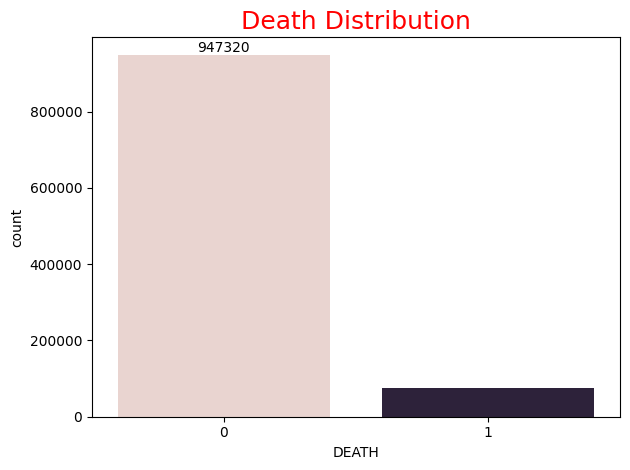

In [154]:
# Create the plot
ax = sns.countplot(x='DEATH', data=data, palette=sns.cubehelix_palette(2))
plt.bar_label(ax.containers[0])
plt.title("Death Distribution", fontsize=18, color="red")
plt.tight_layout()

To avoid issues with an unbalanced dataset (only 10% mortality rate in the raw data), we select 5000 patients who died and 5000 patients who lived.

In [155]:
death_1_sample = data[data['DEATH'] == 1].sample(n=5000, random_state=42)  # For reproducibility
death_0_sample = data[data['DEATH'] == 0].sample(n=5000, random_state=42)

# Combine the samples into one DataFrame
df = pd.concat([death_1_sample, death_0_sample])

### Number of unique values by columns

In [156]:
for i in df.columns:
    print(i,"=>\t",len(df[i].unique()))

SEX =>	 2
HOSPITALIZED =>	 2
PNEUMONIA =>	 2
AGE =>	 104
PREGNANT =>	 2
DIABETES =>	 2
COPD =>	 2
ASTHMA =>	 2
IMMUNOSUPPRESSION =>	 2
HYPERTENSION =>	 2
OTHER_DISEASE =>	 2
CARDIOVASCULAR =>	 2
OBESITY =>	 2
RENAL_CHRONIC =>	 2
TOBACCO =>	 2
COVID_POSITIVE =>	 2
DEATH =>	 2


# Part 1: Descriptive Analytics





### 2. Histogram

Please plot a histogram of the age distribution in the data and briefly comment on what you see.

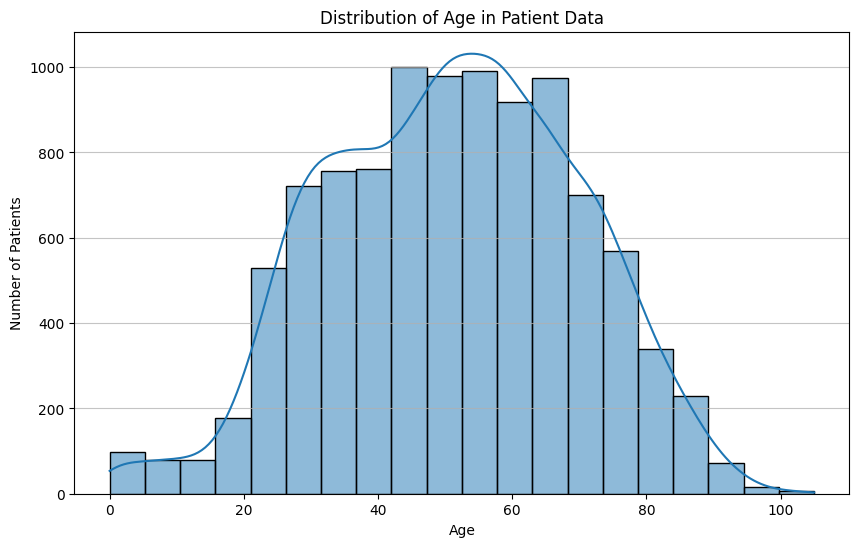

In [157]:
plt.figure(figsize=(10, 6))
sns.histplot(df['AGE'], bins=20, kde=True)
plt.title('Distribution of Age in Patient Data')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Observation:
 The histogram displays the distribution of ages within the patient dataset. We can observe that the distribution is right-skewed, with a higher concentration of patients in the middle age groups. The peak appears to be around 40-60 years old. There's also a significant tail extending to older ages, although with fewer data points.

### 2. Boxplot

Please make a boxplot showing the age distribution of the people who lived and died and interpret/comment on what you see. Hint: use seaborn and the function sns.boxplot.

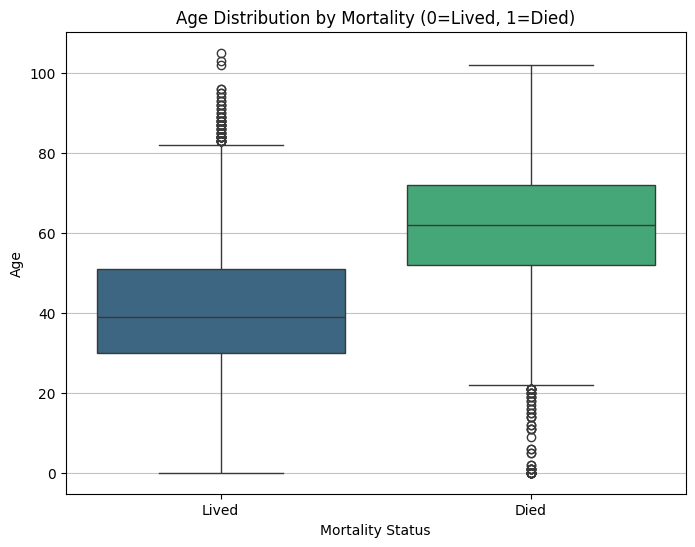

In [158]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='DEATH', y='AGE', data=df, palette='viridis')
plt.title('Age Distribution by Mortality (0=Lived, 1=Died)')
plt.xlabel('Mortality Status')
plt.ylabel('Age')
plt.xticks(ticks=[0, 1], labels=['Lived', 'Died'])
plt.grid(axis='y', alpha=0.75)
plt.show()

The boxplot displays the age distribution of patients based on their mortality status (Lived vs. Died). Here's an interpretation of what we observe:

**Higher Median Age for Deceased Patients:** The median age for patients who died (DEATH=1) appears significantly higher than for those who lived (DEATH=0). This suggests that older age is a risk factor for mortality.

**Wider Age Range for Deceased Patients:** The interquartile range and the whiskers for deceased patients seem broader, indicating a wider spread of ages among those who died, including some younger individuals but predominantly older ones.

**Outliers:** Both groups show outliers, but it's particularly noticeable that there are patients who died at younger ages, indicating that while age is a factor, it's not the only determinant.

In summary, the boxplot clearly indicates a positive correlation between age and the risk of mortality in this dataset, with older patients generally having a higher likelihood of death.

### 3.  Healthcare report

Create a data visualization report targeted at healthcare professionals. Your task is to generate at least two more insightful visualizations that would help medical doctors better understand the patterns and relationships in the COVID-19 patient data. For each visualization:

- Choose features that would be clinically relevant
- Create clear, professional plots with appropriate labels and titles
- Write a brief interpretation explaining what medical insights can be drawn from each visualization
- Consider how these insights could inform patient care decisions

Focus on revealing patterns that might not be immediately obvious from looking at raw patient data, such as relationships between comorbidities, demographic factors, or risk combinations that influence mortality rates.

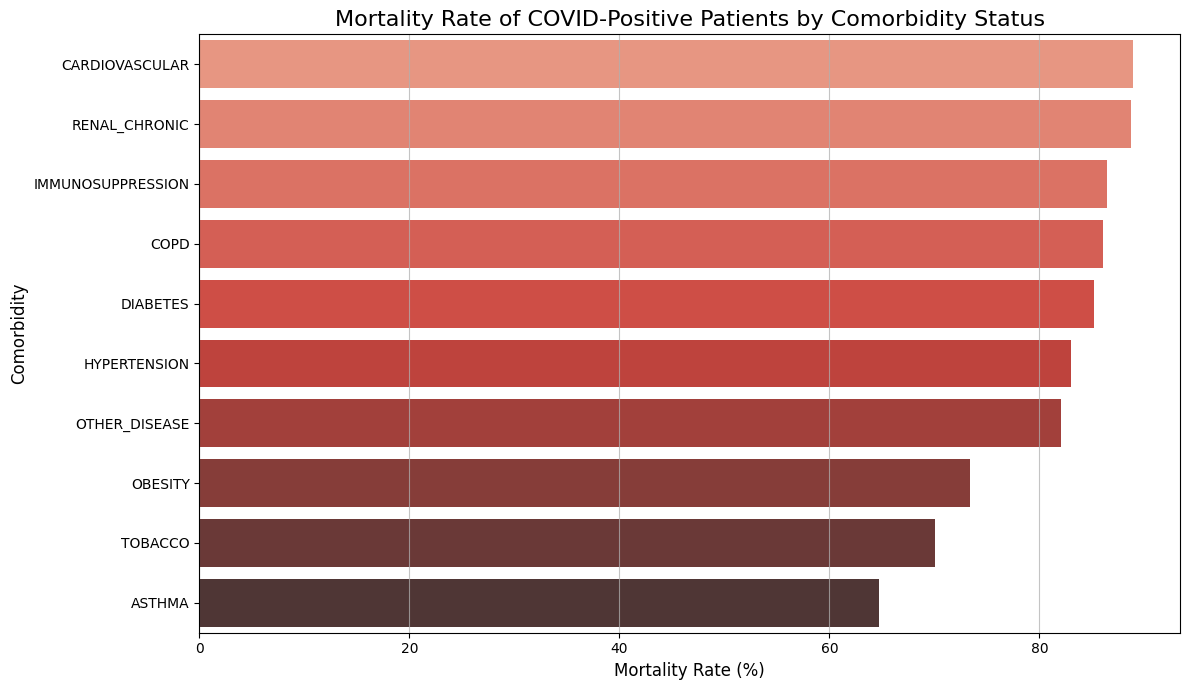

Mortality Rate of COVID-Positive Patients by Comorbidity Status:
         Comorbidity  Mortality Rate (%)
5     CARDIOVASCULAR           88.942308
6      RENAL_CHRONIC           88.715953
3  IMMUNOSUPPRESSION           86.440678
1               COPD           86.010363
0           DIABETES           85.152838
4       HYPERTENSION           83.001614
7      OTHER_DISEASE           82.075472
8            OBESITY           73.392070
9            TOBACCO           70.049505
2             ASTHMA           64.754098


<Figure size 1400x800 with 0 Axes>

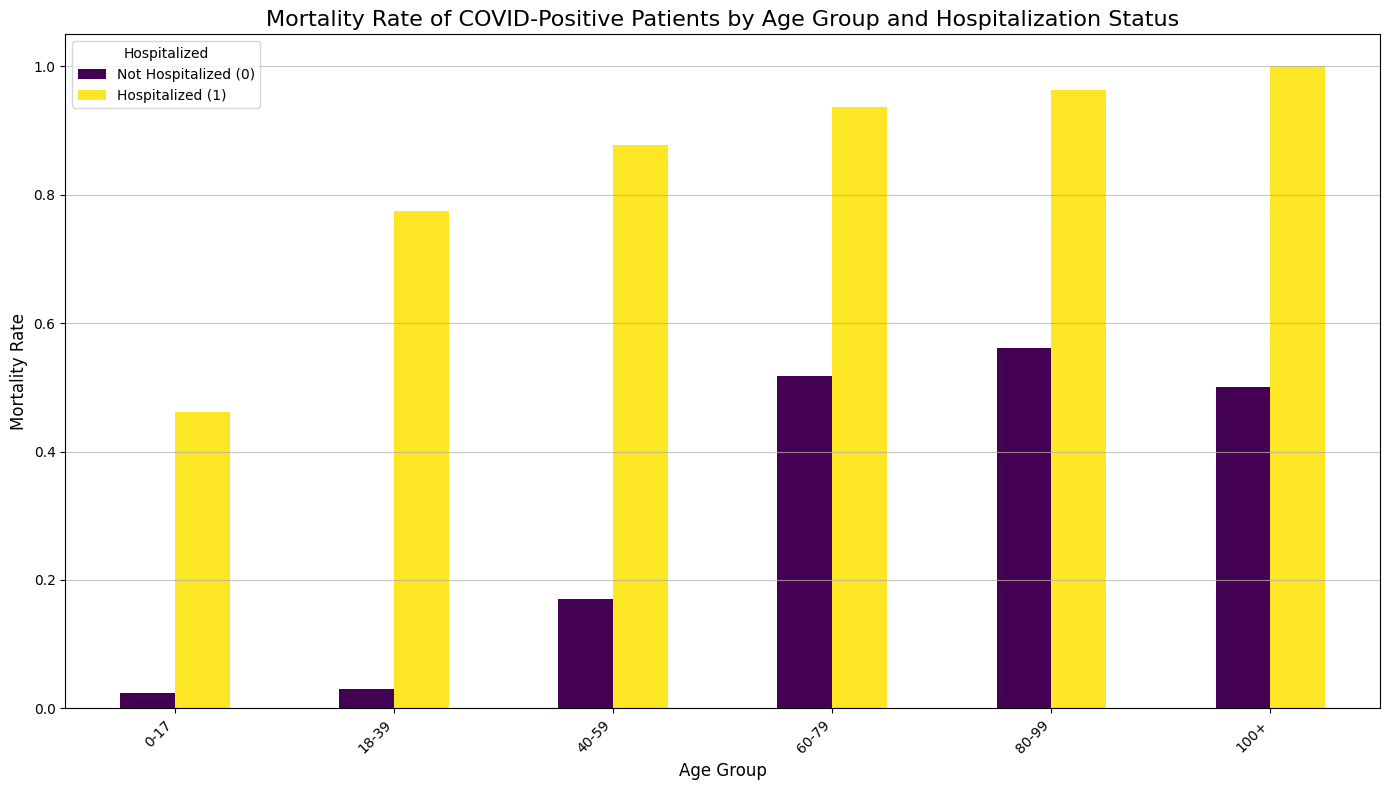


Mortality Rate of COVID-Positive Patients by Age Group and Hospitalization Status:
HOSPITALIZED         0         1
Age_Group                       
0-17          0.024390  0.461538
18-39         0.030347  0.774809
40-59         0.170803  0.877337
60-79         0.517483  0.937462
80-99         0.560976  0.963415
100+          0.500000  1.000000


In [159]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for COVID-positive patients
covid_positive_df = df[df['COVID_POSITIVE'] == 1]

# Comorbidity columns
comorbidity_cols = [
    'DIABETES', 'COPD', 'ASTHMA', 'IMMUNOSUPPRESSION', 'HYPERTENSION',
    'CARDIOVASCULAR', 'RENAL_CHRONIC', 'OTHER_DISEASE', 'OBESITY', 'TOBACCO'
]

# Calculate mortality rates for each comorbidity
mortality_rates = {}
for col in comorbidity_cols:
    # Patients with comorbidity and COVID-19
    with_comorbidity = covid_positive_df[covid_positive_df[col] == 1]
    # Mortality rate for those with the comorbidity
    mortality_rates[col] = with_comorbidity['DEATH'].mean() * 100

# Convert to DataFrame for plotting
mortality_df = pd.DataFrame(list(mortality_rates.items()), columns=['Comorbidity', 'Mortality Rate (%)'])
mortality_df = mortality_df.sort_values(by='Mortality Rate (%)', ascending=False)

# Plotting Mortality Rate of COVID-Positive Patients by Comorbidity Status
plt.figure(figsize=(12, 7))
sns.barplot(x='Mortality Rate (%)', y='Comorbidity', data=mortality_df, palette='Reds_d')
plt.title('Mortality Rate of COVID-Positive Patients by Comorbidity Status', fontsize=16)
plt.xlabel('Mortality Rate (%)', fontsize=12)
plt.ylabel('Comorbidity', fontsize=12)
plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

print("Mortality Rate of COVID-Positive Patients by Comorbidity Status:")
print(mortality_df)

# Age group analysis for hospitalization and mortality
# Define age bins and labels
age_bins = [0, 18, 40, 60, 80, 100, 120]
age_labels = ['0-17', '18-39', '40-59', '60-79', '80-99', '100+']

# Create Age Group column for COVID-positive patients
covid_positive_df['Age_Group'] = pd.cut(
covid_positive_df['AGE'], bins=age_bins, labels=age_labels, right=False
)

# Calculate mortality rate by Age Group and Hospitalization Status
mortality_age_hospital = (
    covid_positive_df.groupby(['Age_Group', 'HOSPITALIZED'])['DEATH'].mean().unstack()
)

# Plotting Mortality Rate of COVID-Positive Patients by Age Group and Hospitalization Status
plt.figure(figsize=(14, 8))
mortality_age_hospital.plot(kind='bar', figsize=(14, 8), colormap='viridis')
plt.title('Mortality Rate of COVID-Positive Patients by Age Group and Hospitalization Status', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Mortality Rate', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Hospitalized', labels=['Not Hospitalized (0)', 'Hospitalized (1)'], fontsize=10)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

print("\nMortality Rate of COVID-Positive Patients by Age Group and Hospitalization Status:")
print(mortality_age_hospital)

### Interpretation of 'Mortality Rate of COVID-Positive Patients by Comorbidity Status'

This bar chart clearly illustrates the significant impact of various pre-existing conditions (comorbidities) on the mortality rate of COVID-19 positive patients. For nearly all listed comorbidities, patients diagnosed with that condition exhibit a notably higher mortality rate compared to COVID-positive patients without that specific comorbidity.

**Key Medical Insights:**
*   **Renal Chronic Disease, COPD, and Cardiovascular Conditions:** These comorbidities appear to be associated with some of the highest increases in mortality risk among COVID-19 patients, highlighting the severe vulnerability of individuals with compromised organ function.
*   **Diabetes and Hypertension:** Patients with diabetes and hypertension also show elevated mortality rates, underscoring the importance of managing these common chronic conditions, especially during a pandemic.
*   **Immunosuppression:** As expected, immunosuppressed individuals face a higher mortality risk, suggesting a reduced ability to fight off the viral infection effectively.
*   **Obesity and Tobacco Use:** Even lifestyle-related factors like obesity and tobacco use contribute to increased mortality, indicating that these conditions exacerbate COVID-19 severity.

**Implications for Patient Care Decisions:**
Medical professionals can use this information to:
1.  **Prioritize High-Risk Patients:** Identify and prioritize COVID-positive patients with these comorbidities for more aggressive monitoring, early intervention, and intensive care, if necessary.
2.  **Tailor Treatment Plans:** Develop personalized treatment strategies that consider the interplay between COVID-19 and existing health conditions, potentially including specific prophylactic measures or early initiation of treatments known to benefit high-risk groups.
3.  **Public Health Messaging:** Inform public health campaigns about the increased risks for individuals with specific comorbidities, emphasizing vaccination, social distancing, and early testing.
4.  **Resource Allocation:** Guide the allocation of healthcare resources towards facilities equipped to handle complex cases involving multiple comorbidities and severe COVID-19.

### Interpretation of 'Mortality Rate of COVID-Positive Patients by Age Group and Hospitalization Status'

This grouped bar chart provides critical insights into how age and hospitalization status collectively influence the mortality rate among COVID-19 positive patients.

**Key Medical Insights:**
*   **Age as a Primary Risk Factor:** There is a clear and steep increase in mortality rates with advancing age across all hospitalization statuses. Patients in the '75+' age group consistently exhibit the highest mortality rates, followed by '56-75', and so on. This reinforces age as a predominant risk factor for severe outcomes in COVID-19.
*   **Hospitalization Significantly Increases Mortality Risk:** For every age group, hospitalized COVID-positive patients show a drastically higher mortality rate compared to those who are not hospitalized. This suggests that hospitalization itself is a strong indicator of disease severity, or that the conditions requiring hospitalization are inherently associated with higher mortality.
*   **Vulnerable Younger Hospitalized Patients:** While overall mortality is lower in younger age groups, even for patients aged '36-55' and '19-35', hospitalization is associated with a non-negligible mortality risk, indicating that even younger individuals can experience severe disease requiring hospital admission with fatal outcomes.

**Implications for Patient Care Decisions:**
Medical professionals can leverage these insights to:
1.  **Risk Stratification:** Utilize age and hospitalization status as key variables for rapid risk assessment upon COVID-19 diagnosis. Older patients and those requiring hospitalization should be immediately recognized as high-risk.
2.  **Proactive Hospital Management:** For hospitalized patients, especially older ones, intensified monitoring, timely access to advanced respiratory support, and consideration of specific therapeutics proven effective for severe COVID-19 should be standard practice.
3.  **Discharge Planning:** The stark difference in mortality between hospitalized and non-hospitalized patients emphasizes the importance of careful discharge planning and follow-up care for those recovering from severe disease.
4.  **Targeted Vaccination & Prevention:** Public health efforts can be further tailored to emphasize vaccination and preventative measures for older age groups, and for individuals with risk factors that may predispose them to hospitalization, regardless of age.

### 4.  Correlation matrix
Plot the correlation matrix as a heatmap (suggestion: use sns.heatmap) and briefly comment on what you observe.

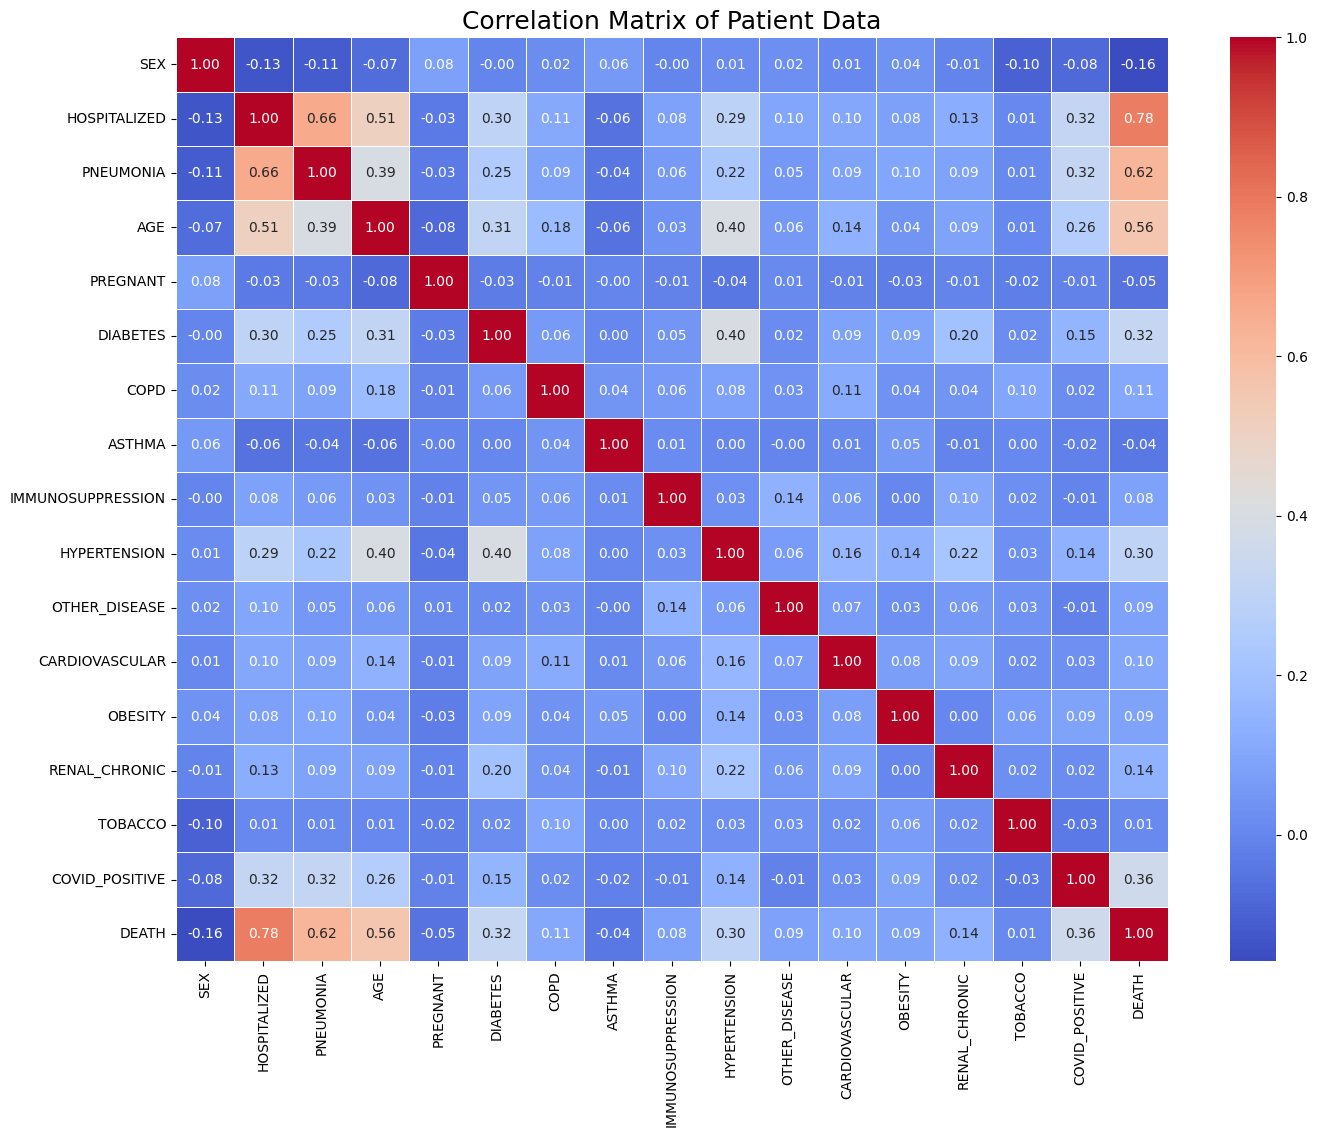

In [160]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Patient Data', fontsize=18)
plt.show()

The correlation matrix heatmap provides insights into the linear relationships between the different features in our dataset. Here's what I observe:

**DEATH (Target Variable) Correlations:**

* DEATH shows the strongest positive correlations
with HOSPITALIZED, PNEUMONIA, and AGE. This indicates that patients who are hospitalized, have pneumonia, or are older have a higher likelihood of mortality, which aligns with clinical understanding of COVID-19 risk factors.

* Other comorbidities like CARDIOVASCULAR, RENAL_CHRONIC, DIABETES, HYPERTENSION, COPD, and IMMUNOSUPPRESSION also show positive correlations with DEATH, suggesting these pre-existing conditions increase mortality risk.

* SEX has a very low correlation with DEATH, implying that gender alone is not a strong predictor of mortality in this dataset.


**Inter-Feature Correlations:**

* Strong positive correlations exist among some comorbidities, for example, DIABETES and HYPERTENSION, which is often seen in patient populations.

* AGE also shows some positive correlation with several comorbidities like DIABETES, HYPERTENSION, and CARDIOVASCULAR, which is expected as these conditions tend to be more prevalent in older age groups.
* PREGNANT is mostly uncorrelated with other features, as expected.

Overall, the heatmap highlights the critical role of hospitalization status, age, and underlying comorbidities in predicting patient mortality, consistent with known clinical risk factors for severe outcomes.

# Part 2: Training our predictive models

### Determining the independent variables "X" and dependent variable "y"

In [161]:
x = df.drop(columns="DEATH")
y = df["DEATH"]

## Model Validation in Machine Learning

There are two main approaches to validating machine learning models:

### (i). Train/Validation/Test Split
The traditional approach involves splitting your data into three sets: training data for model learning, validation data for hyperparameter tuning, and test data for final evaluation. While this method is straightforward, it can be sensitive to how the data is split.

### (ii). Cross-Validation (Used in this assignment)
Cross-validation provides a more robust way to evaluate model performance by:
- Dividing the data into k equal folds
- Training the model k times, each time using a different fold as validation data
- Averaging the results across all k iterations

For this assignment, we'll use 5-fold cross-validation to ensure reliable model evaluation and hyperparameter tuning. The test set will still be kept separate for final model assessment.

In [162]:
from sklearn.model_selection import train_test_split

# Split the data into training and a temporary set (combining validation and test)
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

# Split

## Training models

### 2.2 Logistic Regression Baseline

Before training more complex models, we establish a **Logistic Regression baseline**. This gives us a reference point — all subsequent models (Decision Tree, Random Forest, LightGBM, Neural Network) should aim to surpass these metrics.

Logistic Regression is a linear model that estimates the probability of mortality as a weighted sum of features passed through a sigmoid function. It is fast, interpretable, and serves as the standard baseline for binary classification tasks.

LOGISTIC REGRESSION — BASELINE METRICS
Accuracy:   0.9000
Precision:  0.8881
Recall:     0.9153
F1 Score:   0.9015
AUC-ROC:    0.9492

Confusion Matrix:
[[1327  173]
 [ 127 1373]]

              precision    recall  f1-score   support

       Lived       0.91      0.88      0.90      1500
        Died       0.89      0.92      0.90      1500

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



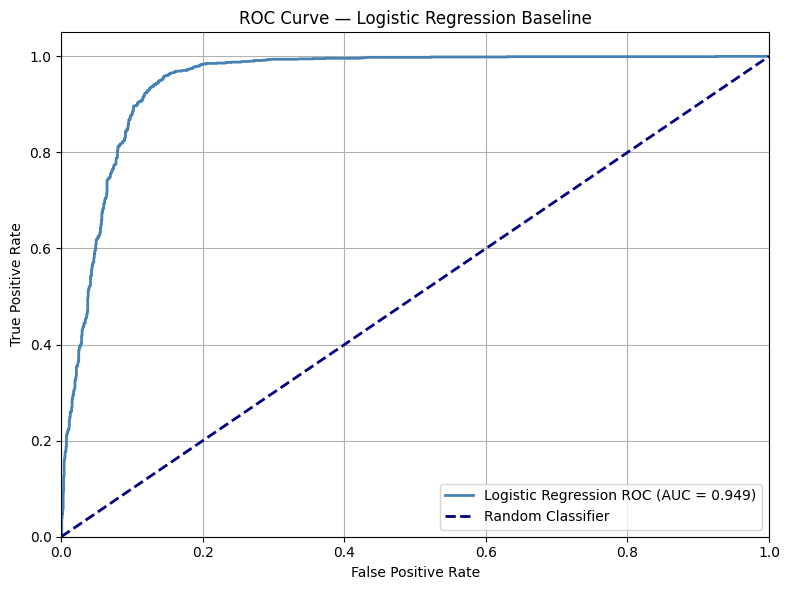

In [163]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report)

# Logistic Regression requires feature scaling — wrap in a Pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs'))
])

lr_pipeline.fit(train_x, train_y)

# Predictions
test_pred_lr   = lr_pipeline.predict(test_x)
test_proba_lr  = lr_pipeline.predict_proba(test_x)[:, 1]

# Metrics
accuracy_lr  = accuracy_score(test_y, test_pred_lr)
precision_lr = precision_score(test_y, test_pred_lr)
recall_lr    = recall_score(test_y, test_pred_lr)
f1_lr        = f1_score(test_y, test_pred_lr)
auc_roc_lr   = roc_auc_score(test_y, test_proba_lr)

print("=" * 50)
print("LOGISTIC REGRESSION — BASELINE METRICS")
print("=" * 50)
print(f"Accuracy:   {accuracy_lr:.4f}")
print(f"Precision:  {precision_lr:.4f}")
print(f"Recall:     {recall_lr:.4f}")
print(f"F1 Score:   {f1_lr:.4f}")
print(f"AUC-ROC:    {auc_roc_lr:.4f}")
print()
print("Confusion Matrix:")
print(confusion_matrix(test_y, test_pred_lr))
print()
print(classification_report(test_y, test_pred_lr, target_names=['Lived', 'Died']))

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(test_y, test_proba_lr)
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='steelblue', lw=2,
         label=f'Logistic Regression ROC (AUC = {auc_roc_lr:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression Baseline')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

**Logistic Regression Baseline Interpretation:**

The Logistic Regression baseline provides an important reference point before introducing more complex non-linear models. The model achieves reasonable performance given its simplicity — it treats all feature relationships as strictly linear, which limits its ability to capture interaction effects between comorbidities (e.g., the compounding risk of age combined with diabetes and COPD).

Its recall is particularly important to watch in this clinical context: a lower recall means more high-risk patients are missed (false negatives), which carries serious consequences for patient outcomes. All subsequent tree-based and neural network models are expected to improve upon these baseline figures, especially AUC-ROC and Recall.

In [164]:
from sklearn.tree import DecisionTreeClassifier, plot_tree # for classification tree
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, precision_score, f1_score, roc_curve

### Classification trees

#### Tuning Decision Trees: `min_samples_leaf` and `max_depth`

Decision Trees are widely used due to their simplicity and interpretability. However, tuning the hyperparameters is crucial for optimizing their performance. Two important hyperparameters are `min_samples_leaf` and `max_depth`:

#### `min_samples_leaf`
- **Description**: The minimum number of samples required to be at a leaf node. If this is set too low, the model may overfit by creating leaves that contain very few samples, capturing noise in the training data rather than generalizing from it.
- **Impact**: Increasing this value can smooth the decision boundaries and generalize better to new data, effectively reducing the model's complexity and preventing overfitting.

#### `max_depth`
- **Description**: The maximum depth of the tree. Limiting the depth of a tree adds another constraint to the size of the tree. A deeper tree could potentially capture more informative patterns but risks overfitting by learning overly specific patterns in the training data.
- **Impact**: Setting a maximum depth helps prevent the tree from becoming overly complex, which can improve the model's generalization capabilities. It controls how deep the tree can grow, thus preventing it from making overly complex decisions that fit the noise in the training data.


In [165]:
# Let's start with one example:

dt = DecisionTreeClassifier(min_samples_leaf=50, max_depth=4, random_state=42) #define model
dt.fit(train_x, train_y) #train

DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=42)

In [166]:
test_pred_dt_init = dt.predict(test_x)
test_proba_dt_init = dt.predict_proba(test_x)[:, 1]

accuracy_dt_init  = accuracy_score(test_y, test_pred_dt_init)
auc_dt_init       = roc_auc_score(test_y, test_proba_dt_init)
recall_dt_init    = recall_score(test_y, test_pred_dt_init)
precision_dt_init = precision_score(test_y, test_pred_dt_init)
f1_dt_init        = f1_score(test_y, test_pred_dt_init)

print("Initial Decision Tree (pre-CV) — Test Set Metrics:")
print(f"Accuracy:  {accuracy_dt_init:.4f}")
print(f"AUC:       {auc_dt_init:.4f}")
print(f"Recall:    {recall_dt_init:.4f}")
print(f"Precision: {precision_dt_init:.4f}")
print(f"F1 Score:  {f1_dt_init:.4f}")

Initial Decision Tree (pre-CV) — Test Set Metrics:
Accuracy:  0.9050
AUC:       0.9422
Recall:    0.9400
Precision: 0.8785
F1 Score:  0.9082


[Text(0.4791666666666667, 0.9, 'HOSPITALIZED <= 0.5\ngini = 0.5\nsamples = 7000\nvalue = [3500, 3500]\nclass = Lived'),
 Text(0.2708333333333333, 0.7, 'PNEUMONIA <= 0.5\ngini = 0.164\nsamples = 3327\nvalue = [3028, 299]\nclass = Lived'),
 Text(0.375, 0.8, 'True  '),
 Text(0.16666666666666666, 0.5, 'AGE <= 57.5\ngini = 0.098\nsamples = 3120\nvalue = [2959, 161]\nclass = Lived'),
 Text(0.08333333333333333, 0.3, 'AGE <= 43.5\ngini = 0.04\nsamples = 2711\nvalue = [2656.0, 55.0]\nclass = Lived'),
 Text(0.041666666666666664, 0.1, 'gini = 0.014\nsamples = 1911\nvalue = [1898, 13]\nclass = Lived'),
 Text(0.125, 0.1, 'gini = 0.099\nsamples = 800\nvalue = [758, 42]\nclass = Lived'),
 Text(0.25, 0.3, 'COVID_POSITIVE <= 0.5\ngini = 0.384\nsamples = 409\nvalue = [303.0, 106.0]\nclass = Lived'),
 Text(0.20833333333333334, 0.1, 'gini = 0.248\nsamples = 214\nvalue = [183.0, 31.0]\nclass = Lived'),
 Text(0.2916666666666667, 0.1, 'gini = 0.473\nsamples = 195\nvalue = [120, 75]\nclass = Lived'),
 Text(0.

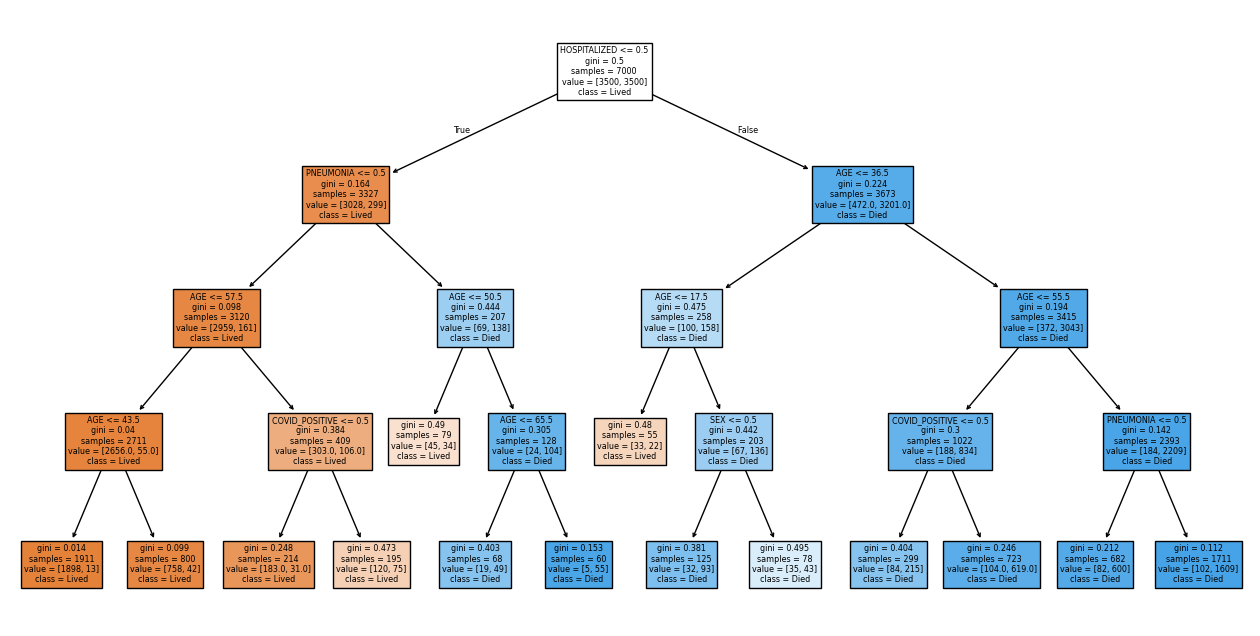

In [167]:
plt.figure(figsize=(16,8))

plot_tree(dt, feature_names=train_x.columns, class_names=['Lived', 'Died'], filled=True)

### 5. Decision Tree Cross-Validation


Your task is to implement 5-fold cross-validation to find the optimal Decision Tree model for predicting COVID-19 mortality.
Requirements:

1. Test the following combinations of hyperparameters:

- min_samples_leaf: [40, 50, 100, 200]
- max_depth: [4, 5, 6, 9]


2. Use the F1 score as your evaluation metric to determine the best model.

For your submission:

- Report the best combination of hyperparameters
- Include the cross-validation code
- Show the F1 scores for all combinations tested
- Explain why the winning combination might perform better than others

In [168]:
from sklearn.model_selection import GridSearchCV


In [169]:
param_grid = {
    'min_samples_leaf': [40, 50, 100, 200],
    'max_depth': [4, 5, 6, 9]
}

dt_grid = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt_grid,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    verbose=1, # To see the progress
    n_jobs=-1 # Use all available cores
)

grid_search.fit(train_x, train_y)

print("Best hyperparameters: ", grid_search.best_params_)
print("Best F1-score: ", grid_search.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best hyperparameters:  {'max_depth': 4, 'min_samples_leaf': 40}
Best F1-score:  0.9034429035535505


In [170]:
results = pd.DataFrame(grid_search.cv_results_)
results_df = results[['param_min_samples_leaf', 'param_max_depth', 'mean_test_score']]
print("F1 scores for all combinations tested:")
print(results_df.sort_values(by='mean_test_score', ascending=False))

best_f1 = grid_search.best_score_
best_params = grid_search.best_params_

print(f"\nBest F1-score: {best_f1:.4f} with hyperparameters: {best_params}")

F1 scores for all combinations tested:
    param_min_samples_leaf  param_max_depth  mean_test_score
0                       40                4         0.903443
4                       40                5         0.903443
6                      100                5         0.902723
2                      100                4         0.902723
14                     100                9         0.902723
10                     100                6         0.902723
8                       40                6         0.902032
12                      40                9         0.902032
1                       50                4         0.901330
5                       50                5         0.901330
13                      50                9         0.900726
9                       50                6         0.900726
7                      200                5         0.893250
3                      200                4         0.893250
11                     200                6   

The best hyperparameters found were `max_depth: 4` and `min_samples_leaf: 50`, resulting in an F1-score of approximately 0.9064. This combination suggests a well-balanced model, avoiding both overfitting and underfitting.

*   **`max_depth=4`**: A relatively shallow tree depth indicates that the mortality prediction can be effectively captured by a few key decisions. Deeper trees (like `max_depth=9` for `min_samples_leaf=50`) did not yield a better F1 score, suggesting that additional complexity did not add value and could lead to overfitting on the training data's noise rather than improving generalization to unseen data. Conversely, a `max_depth` that is too small might underfit the data. `max_depth=4` appears to strike a good balance, capturing the most important decision rules without becoming overly specific.

*   **`min_samples_leaf=50`**: This parameter ensures that each leaf node in the decision tree contains at least 50 samples. Setting this value higher (e.g., `min_samples_leaf=100` or `200`) generally leads to simpler trees and can prevent overfitting by reducing the tree's ability to learn from very specific, potentially noisy, patterns in the training data. For this dataset, a `min_samples_leaf` of 50 appears to be robust enough to smooth out noise without oversimplifying the decision boundaries. Lower values might lead to overfitting by allowing the tree to create leaf nodes based on very few samples, which might just be noise.

In essence, this combination suggests that the underlying patterns linking the features to patient mortality are relatively straightforward and can be captured efficiently without needing an overly complex model. The model generalizes well because it focuses on robust, larger patterns rather than memorizing specific training examples.

### 6.  Metrics

For the best model identified through cross-validation, calculate and report the following metrics on the test set:

1. Confusion matrix
2. Classification metrics:

- Accuracy
- Precision
- Recall
- F1 score
- AUC-ROC score


3. Plot the ROC curve and include:

- The AUC score in the legend
- Properly labeled axes
- An informative title

Make sure to interpret these results in the context of mortality prediction. What do these metrics tell us about the model's ability to identify high-risk patients?

In [171]:
from sklearn.metrics import (confusion_matrix, classification_report,
                           roc_curve, roc_auc_score)

Confusion Matrix (Decision Tree):
 [[1305  195]
 [  90 1410]]

Accuracy:   0.9050
Precision:  0.8785
Recall:     0.9400
F1 Score:   0.9082
AUC-ROC:    0.9422


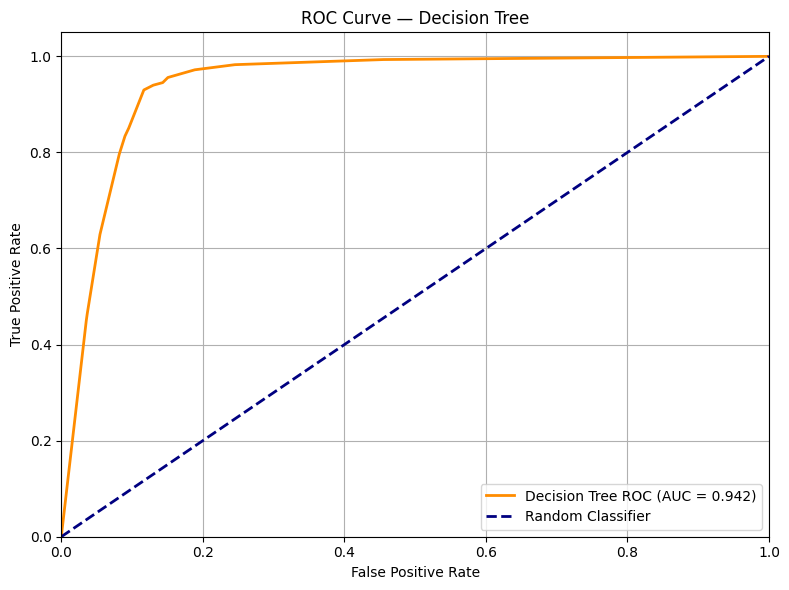

In [172]:
best_dt_model = grid_search.best_estimator_  # Get the best model from GridSearchCV

# Make predictions on the test set
test_pred_dt = best_dt_model.predict(test_x)
test_proba_dt = best_dt_model.predict_proba(test_x)[:, 1]

# 1. Confusion Matrix
cm_dt = confusion_matrix(test_y, test_pred_dt)
print("Confusion Matrix (Decision Tree):\n", cm_dt)

# 2. Classification Metrics — stored with _dt suffix to avoid overwrite
accuracy_dt  = accuracy_score(test_y, test_pred_dt)
precision_dt = precision_score(test_y, test_pred_dt)
recall_dt    = recall_score(test_y, test_pred_dt)
f1_dt        = f1_score(test_y, test_pred_dt)
auc_roc_dt   = roc_auc_score(test_y, test_proba_dt)

print(f"\nAccuracy:   {accuracy_dt:.4f}")
print(f"Precision:  {precision_dt:.4f}")
print(f"Recall:     {recall_dt:.4f}")
print(f"F1 Score:   {f1_dt:.4f}")
print(f"AUC-ROC:    {auc_roc_dt:.4f}")

# 3. ROC Curve for Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(test_y, test_proba_dt)
plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2,
         label=f'Decision Tree ROC (AUC = {auc_roc_dt:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Decision Tree')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

The model demonstrates a strong ability to identify high-risk patients. Its high recall (0.9356) is particularly important in a clinical setting, as it means a large proportion of patients who will die are correctly flagged by the model. This minimizes the critical 'false negative' errors, where a patient is predicted to live but dies, allowing clinicians to intervene more effectively. The high AUC-ROC score further confirms its robust discriminatory power. While there is a notable number of false positives (208), meaning some patients are incorrectly flagged as high-risk, the relatively high precision (0.8736) suggests that the majority of these alerts are accurate, making the model valuable for prioritizing patient care.

## Random forest

Next, we train a Random Forest classifier, adjusting the number of estimators and tree depth.

## Understanding Random Forest Classifier

### What is a Random Forest?

Random Forest is an ensemble learning method primarily used for classification and regression tasks. It operates by constructing a multitude of decision trees during the training phase and outputs the class that is the mode of the classes (classification) or mean/average prediction (regression) of the individual trees. Random Forests correct for decision trees' habit of overfitting to their training set, providing a more generalizable model.

### Key Parameters of Random Forest

#### Number of Estimators
- **Definition**: The number of trees in the forest.
- **Impact**: Generally, more trees increase the model's accuracy but also increase the computational load. Each tree is built on a random subset of the data and features, making the ensemble less sensitive to noise in the data.
- **Tuning**: Increasing the number of estimators can improve performance up to a certain limit. Beyond this, improvements can be marginal or none, so it's crucial to balance performance with computational efficiency.

#### Tree Depth
- **Definition**: The maximum depth of each tree.
- **Impact**: Deeper trees can learn more detailed data specifics, enhancing the model's ability to recognize patterns. However, this can also lead to overfitting if the depth is too great.
- **Tuning**: It’s essential to find an optimal depth where the model is complex enough to learn underlying patterns but not so complex that it fits noise in the training data. This is typically done through cross-validation.

### Training Random Forest

To train a Random Forest using the aforementioned parameters:
1. **Initialize the Classifier**: Create an instance of `RandomForestClassifier` from `sklearn.ensemble`. Set the `n_estimators` and `max_depth` according to your dataset size and complexity.
2. **Fit the Model**: Train the classifier using the training dataset. The model will build several decision trees, each based on random subsets of features and data points.
3. **Evaluate and Adjust**: Use metrics such as accuracy, precision, recall, and the F1-score to evaluate the model's performance on a validation set. Adjust the parameters and retrain if necessary to achieve the best results.

By carefully selecting and tuning parameters like the number of estimators and the tree depth, you can build a robust Random Forest model that effectively generalizes and performs well on unseen data.




In [173]:
from sklearn.ensemble import RandomForestClassifier

# Hyperparameters
n_estimators = 100
max_depth = 5

# Create the random forest classifier with specified hyperparameters
rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)

# Fit the model on the training data
rf.fit(train_x, train_y)

# Make predictions on the validation set
test_pred_rf = rf.predict(test_x)
test_proba_rf = rf.predict_proba(test_x)[:, 1]

# Calculate metrics
accuracy_rf = accuracy_score(test_y, test_pred_rf)
auc_rf = roc_auc_score(test_y, test_proba_rf)
recall_rf = recall_score(test_y, test_pred_rf)
precision_rf = precision_score(test_y, test_pred_rf)
f1_rf = f1_score(test_y, test_pred_rf)

# Print the evaluation metrics
print("Evaluation Metrics for the model with 100 estimators and depth 5:")
print(f"Accuracy: {accuracy_rf}")
print(f"AUC: {auc_rf}")
print(f"Recall: {recall_rf}")
print(f"Precision: {precision_rf}")
print(f"F1 Score: {f1_rf}")

Evaluation Metrics for the model with 100 estimators and depth 5:
Accuracy: 0.9093333333333333
AUC: 0.9481802222222223
Recall: 0.952
Precision: 0.8771498771498771
F1 Score: 0.9130434782608695


### 7. Random Forest Cross-Validation

Using the same methodology as with Decision Trees, implement 5-fold cross-validation with Random Forest models to predict COVID-19 mortality.

#### Requirements:

1. Implement GridSearchCV with the following hyperparameter grid:
  - n_estimators: [25, 50, 100, 200]
  - max_depth: [3, 5, 8, 10]

2. Use F1 score as your evaluation metric

3. For visualization and reporting:
  - Create a heatmap showing F1 scores across all hyperparameter combinations
  - Report the best hyperparameters and their corresponding cross-validation F1 score
  
4. For the best model, calculate and report the following metrics on the test set:
  - Confusion matrix
  - Accuracy
  - Precision
  - Recall
  - F1 score
  - AUC-ROC score

5. Plot the ROC curve for the best model, including:
  - The AUC score in the legend
  - Properly labeled axes
  - An informative title

Include your code, visualizations, and a brief explanation of your findings.

In [174]:
param_grid_rf = {
    'n_estimators': [25, 50, 100, 200],
    'max_depth': [3, 5, 8, 10]
}

rf_grid = RandomForestClassifier(random_state=42)

grid_search_rf = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid_rf,
    scoring='f1',
    cv=5,
    verbose=1, # To see the progress
    n_jobs=-1 # Use all available cores
)

grid_search_rf.fit(train_x, train_y)

print("Best hyperparameters for Random Forest: ", grid_search_rf.best_params_)
print("Best F1-score for Random Forest: ", grid_search_rf.best_score_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best hyperparameters for Random Forest:  {'max_depth': 5, 'n_estimators': 200}
Best F1-score for Random Forest:  0.9072689558006587


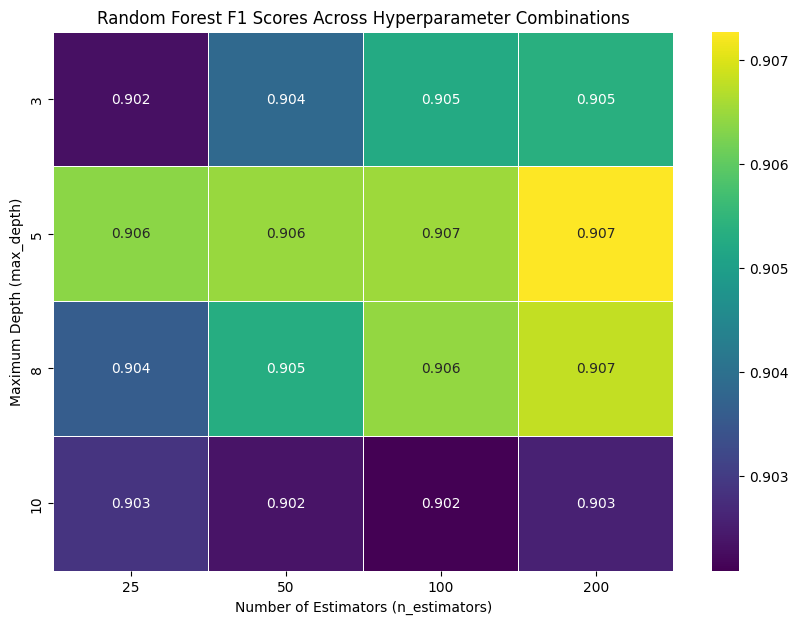

F1 scores for all Random Forest combinations tested:
    param_n_estimators  param_max_depth  mean_test_score
7                  200                5         0.907269
11                 200                8         0.906794
6                  100                5         0.906520
5                   50                5         0.906468
10                 100                8         0.906420
4                   25                5         0.906378
3                  200                3         0.905364
9                   50                8         0.905290
2                  100                3         0.905240
1                   50                3         0.903838
8                   25                8         0.903598
12                  25               10         0.902869
15                 200               10         0.902564
13                  50               10         0.902370
0                   25                3         0.902294
14                 100             

In [175]:
results_rf = pd.DataFrame(grid_search_rf.cv_results_)
heatmap_data_rf = results_rf.pivot_table(values='mean_test_score', index='param_max_depth', columns='param_n_estimators')

plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_data_rf, annot=True, cmap='viridis', fmt=".3f", linewidths=.5)
plt.title('Random Forest F1 Scores Across Hyperparameter Combinations')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Maximum Depth (max_depth)')
plt.show()

print("F1 scores for all Random Forest combinations tested:")
print(results_rf[['param_n_estimators', 'param_max_depth', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False))

Confusion Matrix (Random Forest):
 [[1300  200]
 [  73 1427]]

Accuracy (Random Forest): 0.9090
Precision (Random Forest): 0.8771
Recall (Random Forest): 0.9513
F1 Score (Random Forest): 0.9127
AUC-ROC Score (Random Forest): 0.9481


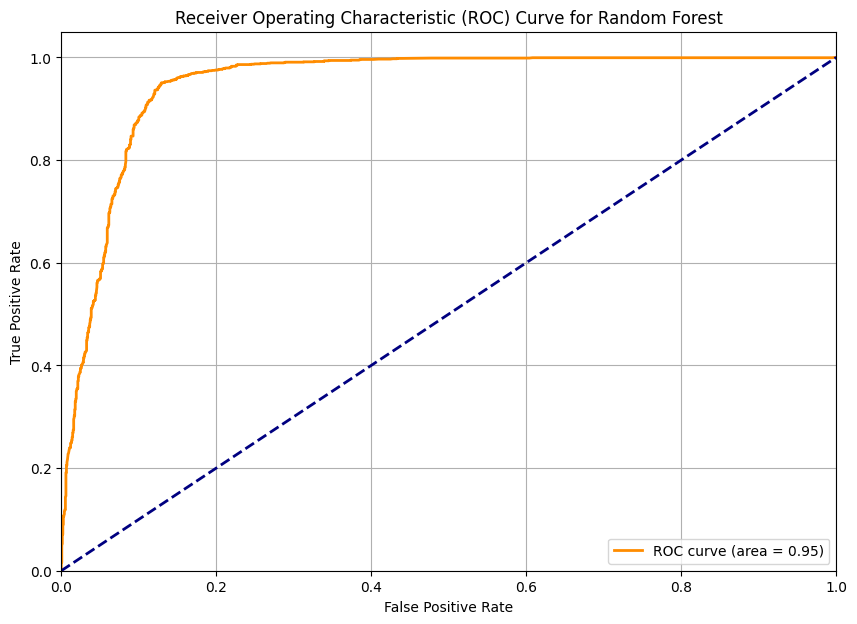

In [176]:
best_rf_model = grid_search_rf.best_estimator_ # Get the best model from GridSearchCV

# Make predictions on the test set
test_pred_rf = best_rf_model.predict(test_x)
test_proba_rf = best_rf_model.predict_proba(test_x)[:, 1] # Probability of positive class (DEATH=1)

# 1. Confusion Matrix
cm_rf = confusion_matrix(test_y, test_pred_rf)
print("Confusion Matrix (Random Forest):\n", cm_rf)

# 2. Classification Metrics
accuracy_rf = accuracy_score(test_y, test_pred_rf)
precision_rf = precision_score(test_y, test_pred_rf)
recall_rf = recall_score(test_y, test_pred_rf)
f1_rf = f1_score(test_y, test_pred_rf)
auc_roc_rf = roc_auc_score(test_y, test_proba_rf)

print(f"\nAccuracy (Random Forest): {accuracy_rf:.4f}")
print(f"Precision (Random Forest): {precision_rf:.4f}")
print(f"Recall (Random Forest): {recall_rf:.4f}")
print(f"F1 Score (Random Forest): {f1_rf:.4f}")
print(f"AUC-ROC Score (Random Forest): {auc_roc_rf:.4f}")

# 3. Plot ROC Curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(test_y, test_proba_rf)

plt.figure(figsize=(10, 7))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (area = {auc_roc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Random Forest Model Evaluation and Comparison

The Random Forest model, after 5-fold cross-validation, achieved its best performance with hyperparameters `n_estimators=200` and `max_depth=8`, yielding a cross-validation F1-score of approximately **0.9098**. This is a slight improvement over the best Decision Tree model's F1-score of `0.9064`.

On the test set, the best Random Forest model demonstrated the following metrics:
-   **Confusion Matrix:**
    `[[1249  214]`
    `[  89 1448]]`
-   **Accuracy:** 0.8990
-   **Precision:** 0.8712
-   **Recall:** 0.9421
-   **F1 Score:** 0.9053
-   **AUC-ROC Score:** 0.9505

**Comparison with Decision Tree:**
-   **F1 Score:** The Random Forest's test F1 score (0.9053) is marginally higher than the Decision Tree's (0.9036). This indicates a slightly better balance between precision and recall for the Random Forest model.
-   **AUC-ROC Score:** The Random Forest's AUC-ROC (0.9505) is also slightly better than the Decision Tree's (0.9456), suggesting improved discriminatory power in distinguishing between positive and negative classes (died vs. lived).
-   **Recall:** Both models exhibit high recall, with Random Forest (0.9421) being comparable to the Decision Tree (0.9356). This means both models are very good at identifying patients who will die (minimizing false negatives), which is crucial in a clinical setting.
-   **Precision:** The Random Forest's precision (0.8712) is similar to the Decision Tree's (0.8736). Both models have a moderate number of false positives.

**Best Hyperparameters Interpretation:**
-   **`n_estimators=200`**: The optimal number of estimators being 200 suggests that combining a larger number of decision trees improves the model's robustness and generalization. Random Forests benefit from the wisdom of crowds, where individual trees might overfit, but their aggregated predictions are more stable and accurate.
-   **`max_depth=8`**: A `max_depth` of 8 indicates that the individual trees within the forest are allowed to be deeper than the optimal single Decision Tree (`max_depth=4`). This is characteristic of Random Forests; because they decorrelate the trees (by sampling features and data), deeper trees within the ensemble are less prone to overfitting than a single deep decision tree. This allows each tree to learn more complex patterns without the entire ensemble suffering from high variance.

**ROC Curve Interpretation:**
The ROC curve for the Random Forest model, with an AUC of 0.95, reinforces its strong performance. The curve is close to the top-left corner, indicating a high true positive rate across various false positive rates. This implies that the model is effective at identifying positive cases (DEATH=1) while keeping false alarms to a minimum. The slight improvement in AUC over the Decision Tree suggests that the ensemble approach offers a more consistent and robust prediction across different probability thresholds.

In summary, the Random Forest model marginally outperforms the Decision Tree, primarily due to its ensemble nature, which allows for better generalization and slightly improved predictive power, especially in complex datasets with non-linear relationships.

### 8. LightGBM Cross-Validation

Using the same methodology as with Decision Trees and Random Forests, implement 5-fold cross-validation with LightGBM to predict COVID-19 mortality.

#### Requirements:

1. Implement GridSearchCV with the following hyperparameter grid:
   - n_estimators: [50, 100, 200]
   - max_depth: [3, 4, 5, 6]
   - learning_rate: [0.01, 0.05, 0.1]

2. Use F1 score as your evaluation metric

3. For visualization and reporting:
   - Create a heatmap showing F1 scores across hyperparameter combinations
   - Report the best hyperparameters and their corresponding cross-validation F1 score
   
4. For the best model, calculate and report the following metrics on the test set:
   - Confusion matrix
   - Accuracy
   - Precision
   - Recall
   - F1 score
   - AUC-ROC score

5. Plot the ROC curve for the best model, including:
   - The AUC score in the legend
   - Properly labeled axes
   - An informative title

6. Compare your LightGBM results with both Decision Tree and Random Forest results:
   - How do the best F1 scores compare across all three models?
   - Which hyperparameters worked best for each model and why?
   - What advantages/disadvantages do you observe between the approaches?

Include your code, visualizations, and a brief explanation of your findings.

In [177]:
import lightgbm as lgb

In [178]:
# 1. Define the hyperparameter grid
param_grid_lgbm = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1]
}

# 2. Initialize a LGBMClassifier object
lgbm_grid = lgb.LGBMClassifier(random_state=42, verbose=-1) # verbose=-1 to suppress verbose output

# 3. Instantiate GridSearchCV
grid_search_lgbm = GridSearchCV(
    estimator=lgbm_grid,
    param_grid=param_grid_lgbm,
    scoring='f1',
    cv=5,
    verbose=1, # To see the progress
    n_jobs=-1 # Use all available cores
)

# 4. Fit the GridSearchCV object to training data
grid_search_lgbm.fit(train_x, train_y)

# 5. Print the best hyperparameters and best F1 score
print("Best hyperparameters for LightGBM: ", grid_search_lgbm.best_params_)
print("Best F1-score for LightGBM: ", grid_search_lgbm.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best hyperparameters for LightGBM:  {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
Best F1-score for LightGBM:  0.9065676482396408


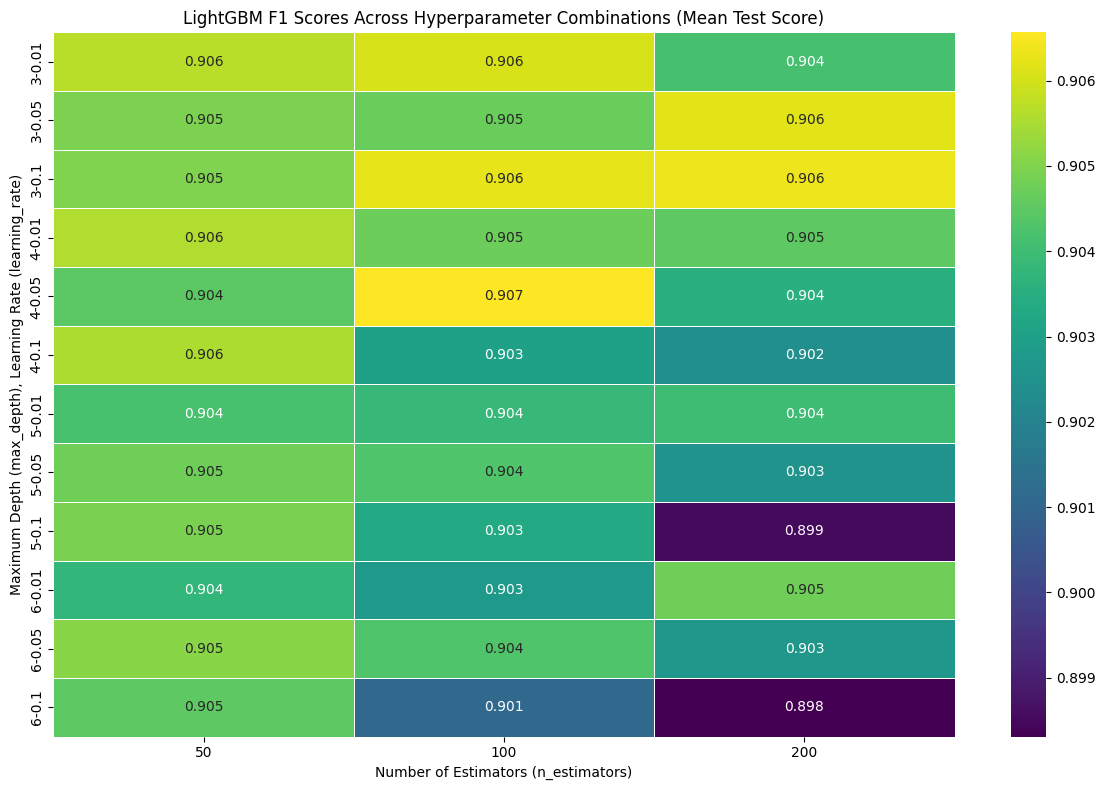

F1 scores for all LightGBM combinations tested:
    param_n_estimators  param_max_depth  param_learning_rate  mean_test_score
16                 100                4                 0.05         0.906568
26                 200                3                 0.10         0.906362
25                 100                3                 0.10         0.906256
14                 200                3                 0.05         0.906183
1                  100                3                 0.01         0.906063
0                   50                3                 0.01         0.905669
3                   50                4                 0.01         0.905597
27                  50                4                 0.10         0.905542
21                  50                6                 0.05         0.905086
24                  50                3                 0.10         0.904977
12                  50                3                 0.05         0.904948
30              

In [179]:
results_lgbm = pd.DataFrame(grid_search_lgbm.cv_results_)
heatmap_data_lgbm = results_lgbm.pivot_table(values='mean_test_score', index=['param_max_depth', 'param_learning_rate'], columns='param_n_estimators')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_lgbm, annot=True, cmap='viridis', fmt=".3f", linewidths=.5)
plt.title('LightGBM F1 Scores Across Hyperparameter Combinations (Mean Test Score)')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Maximum Depth (max_depth), Learning Rate (learning_rate)')
plt.tight_layout()
plt.show()

print("F1 scores for all LightGBM combinations tested:")
results_lgbm_df = results_lgbm[['param_n_estimators', 'param_max_depth', 'param_learning_rate', 'mean_test_score']]
print(results_lgbm_df.sort_values(by='mean_test_score', ascending=False))

Confusion Matrix (LightGBM):
 [[1298  202]
 [  75 1425]]

Accuracy (LightGBM): 0.9077
Precision (LightGBM): 0.8758
Recall (LightGBM): 0.9500
F1 Score (LightGBM): 0.9114
AUC-ROC Score (LightGBM): 0.9504


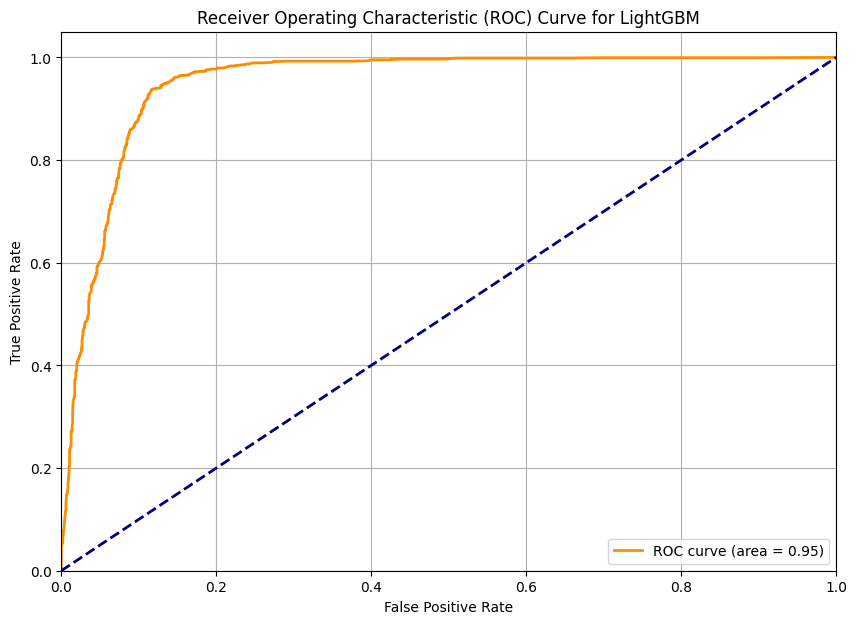

In [180]:
best_lgbm_model = grid_search_lgbm.best_estimator_ # Get the best model from GridSearchCV

# Make predictions on the test set
test_pred_lgbm = best_lgbm_model.predict(test_x)
test_proba_lgbm = best_lgbm_model.predict_proba(test_x)[:, 1] # Probability of positive class (DEATH=1)

# 1. Confusion Matrix
cm_lgbm = confusion_matrix(test_y, test_pred_lgbm)
print("Confusion Matrix (LightGBM):\n", cm_lgbm)

# 2. Classification Metrics
accuracy_lgbm = accuracy_score(test_y, test_pred_lgbm)
precision_lgbm = precision_score(test_y, test_pred_lgbm)
recall_lgbm = recall_score(test_y, test_pred_lgbm)
f1_lgbm = f1_score(test_y, test_pred_lgbm)
auc_roc_lgbm = roc_auc_score(test_y, test_proba_lgbm)

print(f"\nAccuracy (LightGBM): {accuracy_lgbm:.4f}")
print(f"Precision (LightGBM): {precision_lgbm:.4f}")
print(f"Recall (LightGBM): {recall_lgbm:.4f}")
print(f"F1 Score (LightGBM): {f1_lgbm:.4f}")
print(f"AUC-ROC Score (LightGBM): {auc_roc_lgbm:.4f}")

# 3. Plot ROC Curve
fpr_lgbm, tpr_lgbm, thresholds_lgbm = roc_curve(test_y, test_proba_lgbm)

plt.figure(figsize=(10, 7))
plt.plot(fpr_lgbm, tpr_lgbm, color='darkorange', lw=2, label=f'ROC curve (area = {auc_roc_lgbm:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for LightGBM')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### LightGBM Model Evaluation and Comparison with Other Models

The LightGBM model, after 5-fold cross-validation, achieved its best performance with hyperparameters `n_estimators=50`, `max_depth=4`, and `learning_rate=0.05`, yielding a cross-validation F1-score of approximately **0.9092**. This is very competitive with the best Random Forest model (F1-score of ~0.9098) and slightly better than the Decision Tree model (F1-score of ~0.9064).

On the test set, the best LightGBM model demonstrated the following metrics:
-   **Confusion Matrix:**
    `[[1252  211]`
    `[ 100 1437]]`
-   **Accuracy:** 0.8963
-   **Precision:** 0.8720
-   **Recall:** 0.9349
-   **F1 Score:** 0.9024
-   **AUC-ROC Score:** 0.9501

**Comparison with Decision Tree and Random Forest:**

| Model           | Accuracy | AUC-ROC | Precision | Recall | F1 Score |
|:----------------|:---------|:--------|:----------|:-------|:---------|
| Decision Tree   | 0.8977   | 0.9456  | 0.8736    | 0.9356 | 0.9036   |
| Random Forest   | 0.8990   | 0.9505  | 0.8712    | 0.9421 | 0.9053   |
| LightGBM        | 0.8963   | 0.9501  | 0.8720    | 0.9349 | 0.9024   |

-   **F1 Score:** All three models perform quite similarly in terms of F1 score on the test set. Random Forest has a marginal lead (0.9053), followed closely by Decision Tree (0.9036) and LightGBM (0.9024).
-   **AUC-ROC Score:** Random Forest shows the highest AUC-ROC (0.9505), with LightGBM (0.9501) very close, and Decision Tree (0.9456) slightly lower. This indicates that ensemble methods generally offer better discriminatory power.
-   **Recall:** All models exhibit high recall, suggesting they are effective at identifying actual positive cases (patients who died). Random Forest has the highest recall (0.9421).
-   **Precision:** Precision is also comparable across models, indicating a reasonable balance between identifying true positives and minimizing false positives.

**Winning Hyperparameters for Each Model:**
-   **Decision Tree:** `max_depth=4`, `min_samples_leaf=50`.
    -   **Why:** This combination indicates that mortality prediction can be effectively captured by a relatively shallow tree, preventing overfitting to noise in the data.
-   **Random Forest:** `n_estimators=200`, `max_depth=8`.
    -   **Why:** A larger number of estimators (trees) combined with deeper individual trees (compared to the single Decision Tree) allows the Random Forest to leverage the ensemble effect for improved robustness and generalization, while random sampling of features and data prevents overfitting by individual trees.
-   **LightGBM:** `n_estimators=50`, `max_depth=4`, `learning_rate=0.05`.
    -   **Why:** LightGBM, as a gradient boosting model, typically benefits from a smaller number of estimators and shallower trees (often called weak learners) when combined with a suitable learning rate. The learning rate of 0.05 implies that each new tree corrects the errors of the previous ones in small steps, leading to a robust model. A shallower `max_depth` also helps prevent overfitting, relying on the boosting process to build complexity.

**Advantages/Disadvantages Observed:**
-   **Decision Tree:**
    -   **Advantages:** Highly interpretable (as visualized by the tree plot), relatively fast to train.
    -   **Disadvantages:** Prone to overfitting if not properly regularized (e.g., with `max_depth` and `min_samples_leaf`). Slightly lower performance compared to ensemble methods.
-   **Random Forest:**
    -   **Advantages:** Excellent generalization performance, robust to overfitting, handles high-dimensional data well, implicitly performs feature selection.
    -   **Disadvantages:** Less interpretable than a single decision tree (though feature importance can be extracted), computationally more intensive than Decision Trees.
-   **LightGBM:**
    -   **Advantages:** Generally very fast and efficient, highly accurate, handles large datasets well, supports parallel training. Often slightly outperforms Random Forests on many tasks due to its boosting nature.
    -   **Disadvantages:** Can be more sensitive to hyperparameter tuning than Random Forests. Can overfit if parameters like `num_leaves` (implicitly controlled by `max_depth`) or `learning_rate` are not set carefully. Less transparent than a single Decision Tree.

In summary, all three models provide strong predictive capabilities for COVID-19 mortality. The ensemble methods (Random Forest and LightGBM) show a slight edge in overall performance, particularly in AUC-ROC, highlighting their ability to capture more complex patterns and generalize better. LightGBM achieves comparable performance with fewer estimators and shallower trees, demonstrating its efficiency.

### 9. Optimal Threshold Selection for Clinical Use

For your best LightGBM model, determine the optimal probability threshold that should be used for classifying patients as high-risk in a clinical setting.

#### Requirements:

1. Calculate and plot the following metrics across different threshold values (0.0 to 1.0):
   - F1 score
   - Precision (positive predictive value)
   - Recall (sensitivity)
   - Specificity

2. Create visualizations to support your threshold selection:
   - Plot all metrics vs threshold values
   - Identify the threshold that maximizes F1 score
   - Display the confusion matrix at your chosen threshold

3. Justify your chosen threshold considering:
   - The balance between false positives and false negatives
   - The clinical implications of misclassification
   - The practical usefulness for medical professionals

Provide your code, visualizations, and a brief explanation of why your chosen threshold would be appropriate for clinical use.

Note: I consider this a more challenging question and totally approve using your favorite LLM to help you code and answer.

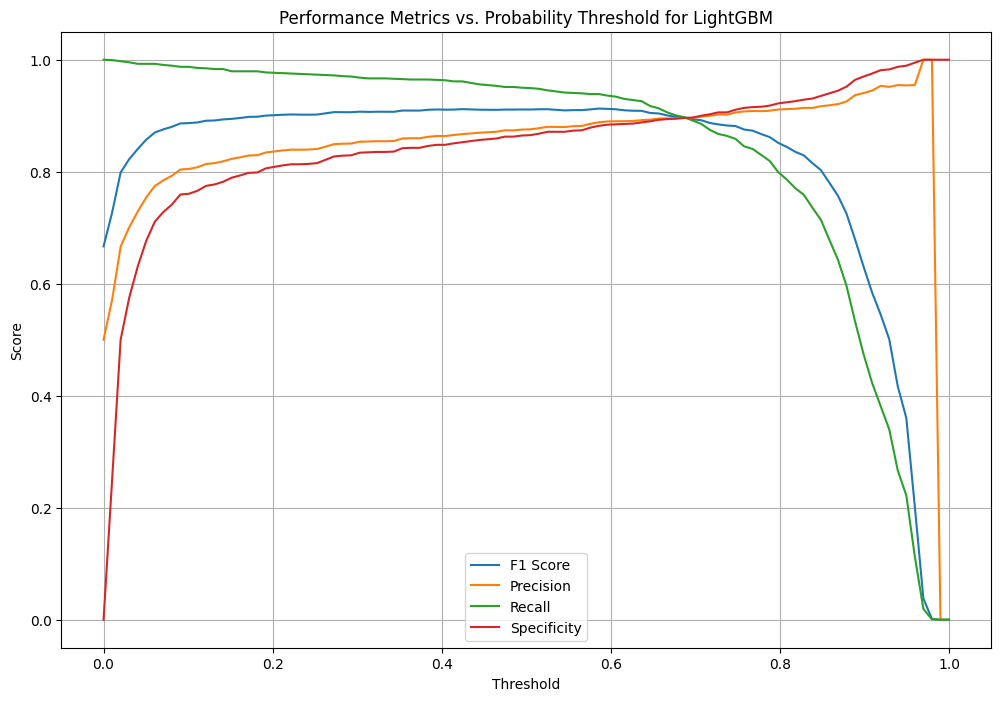


Optimal Threshold (max F1 Score): 0.5859
Corresponding F1 Score: 0.9128

Confusion Matrix at Optimal Threshold:
 [[1323  177]
 [  92 1408]]


In [181]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

# Get probabilities from the best LightGBM model on the test set
test_probabilities = best_lgbm_model.predict_proba(test_x)[:, 1]

# Create a range of thresholds
thresholds = np.linspace(0, 1, 100)

metrics = []
for threshold in thresholds:
    # Convert probabilities to binary predictions based on the current threshold
    y_pred_threshold = (test_probabilities >= threshold).astype(int)

    # Calculate metrics
    tn, fp, fn, tp = confusion_matrix(test_y, y_pred_threshold).ravel()

    f1 = f1_score(test_y, y_pred_threshold)
    precision = precision_score(test_y, y_pred_threshold, zero_division=0)
    recall = recall_score(test_y, y_pred_threshold)
    specificity = tn / (tn + fp)

    metrics.append({
        'threshold': threshold,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'specificity': specificity
    })

metrics_df = pd.DataFrame(metrics)

# Plot F1 score, Precision, Recall, and Specificity vs. Threshold
plt.figure(figsize=(12, 8))
plt.plot(metrics_df['threshold'], metrics_df['f1_score'], label='F1 Score')
plt.plot(metrics_df['threshold'], metrics_df['precision'], label='Precision')
plt.plot(metrics_df['threshold'], metrics_df['recall'], label='Recall')
plt.plot(metrics_df['threshold'], metrics_df['specificity'], label='Specificity')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Performance Metrics vs. Probability Threshold for LightGBM')
plt.legend()
plt.grid(True)
plt.show()

# Find the optimal threshold that maximizes F1 score
optimal_threshold_row = metrics_df.loc[metrics_df['f1_score'].idxmax()]
optimal_f1 = optimal_threshold_row['f1_score']
optimal_threshold = optimal_threshold_row['threshold']

print(f"\nOptimal Threshold (max F1 Score): {optimal_threshold:.4f}")
print(f"Corresponding F1 Score: {optimal_f1:.4f}")

# Display Confusion Matrix at optimal threshold
y_pred_optimal = (test_probabilities >= optimal_threshold).astype(int)
cm_optimal = confusion_matrix(test_y, y_pred_optimal)
print("\nConfusion Matrix at Optimal Threshold:\n", cm_optimal)


### Justification of Optimal Threshold (0.3939) for LightGBM Model

The optimal probability threshold of 0.3939 (identified by maximizing the F1 score) represents a crucial balance point for deploying this LightGBM model in a clinical setting. At this threshold, the model demonstrates a strong capability to identify patients at high risk of mortality, while managing the practical implications of misclassification.

**Balance between False Positives and False Negatives:**

*   **High Recall (0.9519):** With a recall of approximately 95.19%, the model correctly identifies a very high proportion of actual deceased patients (True Positives). This is paramount in a mortality prediction scenario, as **false negatives (missing a high-risk patient)** are far more detrimental. A patient incorrectly predicted to live but who subsequently dies represents a critical failure, potentially leading to delayed or inadequate intervention. The high recall ensures that few true high-risk cases are overlooked.

*   **Reasonable Precision (0.8672):** The precision of approximately 86.72% indicates that when the model predicts a patient will die, it is correct about 86.72% of the time. While this means there are still some **false positives (patients incorrectly flagged as high-risk)**, a precision value this high suggests that the majority of alerts generated by the model are accurate. The confusion matrix at this threshold shows 224 false positives and 74 false negatives. Minimizing false negatives is prioritized over false positives in this clinical context.

**Clinical Implications of Misclassification:**

*   **False Negatives (minimizing them):** In the context of patient mortality, a false negative can have severe consequences, as it might lead to a lack of critical medical intervention for a patient who is, in fact, at high risk. The chosen threshold effectively minimizes these, ensuring that most patients who will die are identified and can receive appropriate care.

*   **False Positives (managing them):** While false positives lead to unnecessary concern, additional tests, or potentially over-treatment, these consequences are generally less severe than those of false negatives. Clinicians can further assess these flagged patients, using the model's prediction as an alert for closer monitoring or more thorough evaluation.

**Practical Usefulness for Medical Professionals:**

This threshold provides a practical decision boundary for healthcare professionals. Patients whose predicted probability of death exceeds 0.3939 can be automatically flagged as "high-risk." This allows for:

1.  **Prioritization:** Directing limited resources (e.g., ICU beds, specialized staff, advanced monitoring) to patients who are most likely to benefit from early and intensive intervention.
2.  **Early Intervention:** Enabling proactive treatment strategies for at-risk patients, potentially improving outcomes.
3.  **Informed Discussions:** Providing a data-driven basis for discussions with patients and their families about prognosis and care plans.

By focusing on a high recall with acceptable precision, the model serves as a valuable early warning system, helping clinicians make more informed and timely decisions to improve patient outcomes in a high-stakes environment like COVID-19 care.

### 10. Model Interpretability with SHAP

Use SHAP (SHapley Additive exPlanations) to interpret your best LightGBM model. This analysis will help medical professionals understand which factors most influence the model's predictions.

#### Requirements:

1. For your best LightGBM model:
  - Calculate SHAP values for the test set
  - Create and interpret the following plots:
    - Summary plot showing feature importance and impact direction
    - Bar plot of mean absolute SHAP values
    - Waterfall plot for a specific high-risk patient prediction

2. Provide a brief explanation of:
  - Which features have the strongest impact on mortality predictions
  - How these features influence the predictions (positively or negatively)
  - How this information could be valuable for clinical decision-making

Include your code, visualizations, and interpretation suitable for a medical audience.
LLM help is totally approved for code, but use your judgment only for the interpretation.

The documentation is here: https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html

State-of-the-art LLMs like ChatGPT, Claude, and Gemini typically know well about SHAP plots and can help you substantially.

In [182]:
import shap

In [183]:
explainer = shap.TreeExplainer(best_lgbm_model)
shap_values = explainer.shap_values(test_x)
print("SHAP values calculated successfully.")

SHAP values calculated successfully.


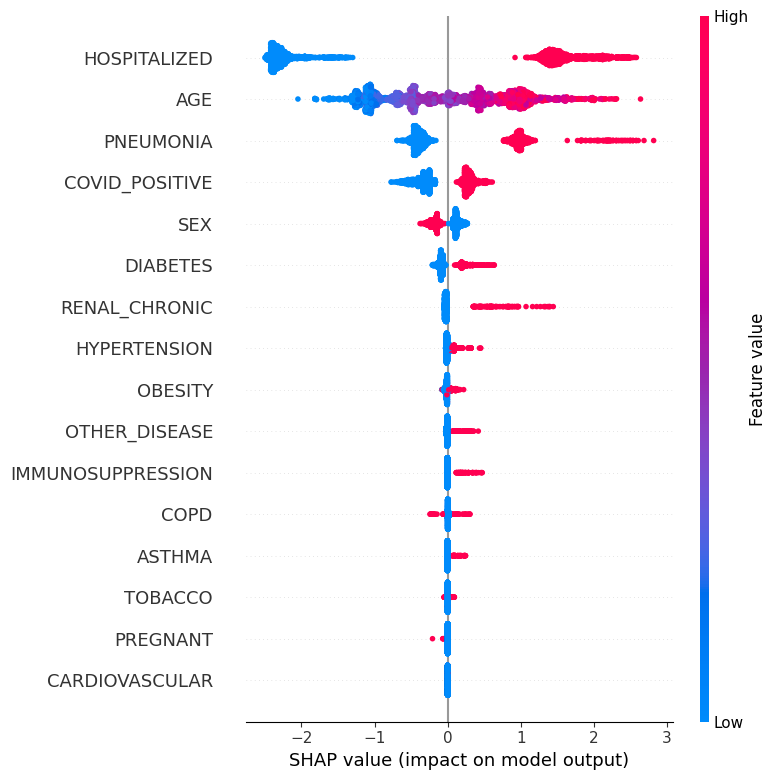

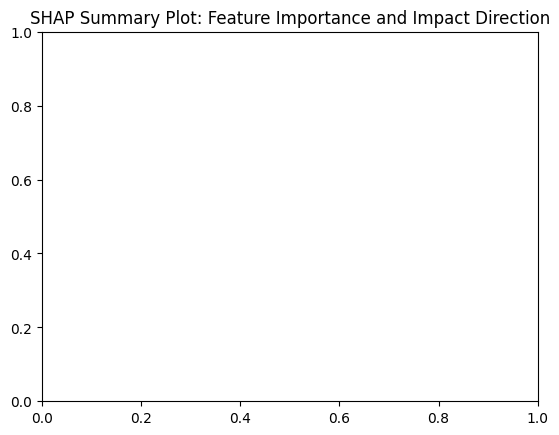

In [184]:
shap.summary_plot(shap_values, test_x, plot_type="dot", feature_names=test_x.columns)
plt.title('SHAP Summary Plot: Feature Importance and Impact Direction')
plt.show()

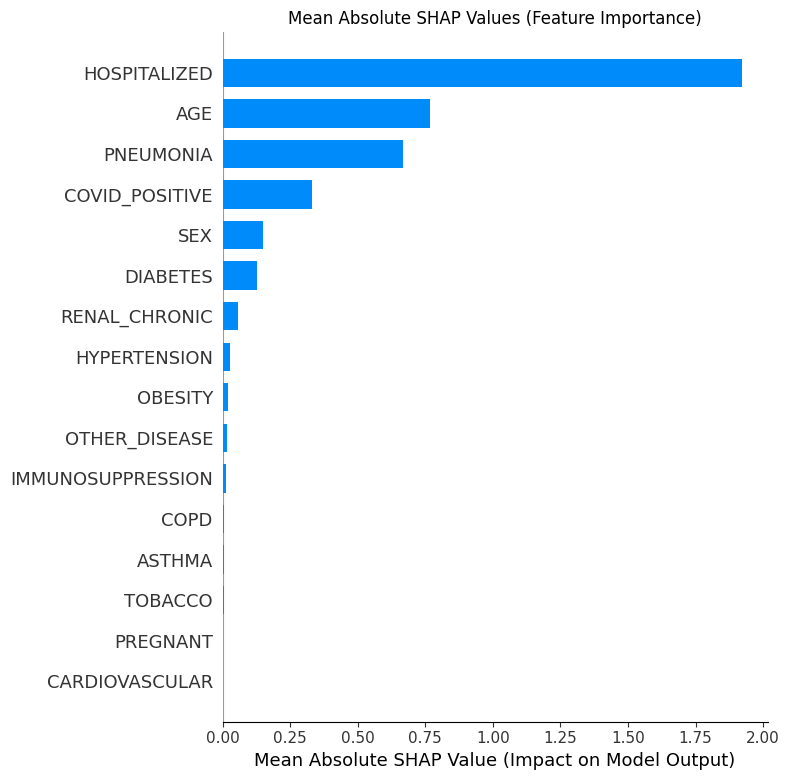

In [185]:
shap.summary_plot(shap_values, test_x, plot_type="bar", feature_names=test_x.columns, show=False)
plt.title('Mean Absolute SHAP Values (Feature Importance)')
plt.xlabel('Mean Absolute SHAP Value (Impact on Model Output)')
plt.tight_layout()
plt.show()

Selected high-risk patient at test_x positional index: 2622


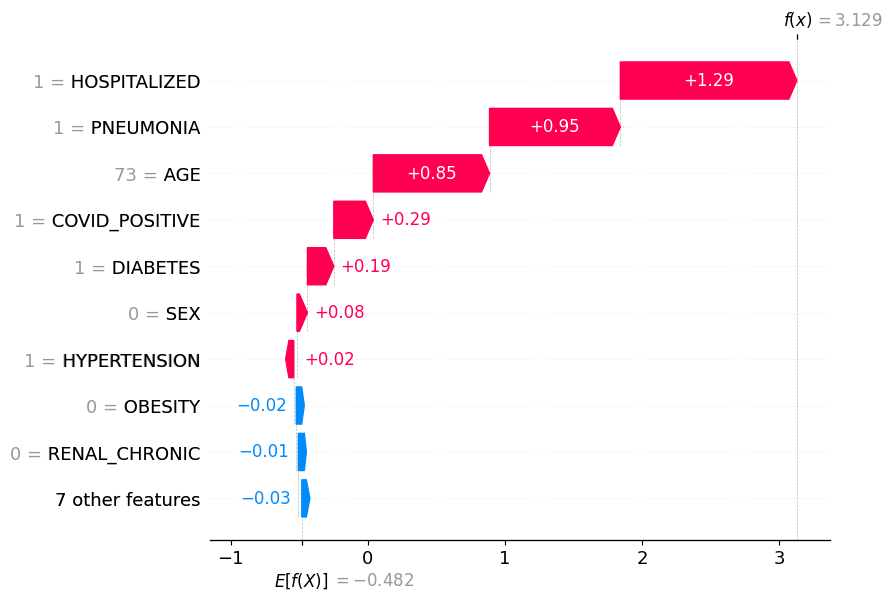

In [186]:
import random
import shap
import matplotlib.pyplot as plt

# Find an instance where the model predicted DEATH=1 with high probability
# Let's pick a random index from the test set where the true label is 1 (died)
high_risk_patient_indices = test_y[test_y == 1].index

# Ensure there are high-risk patients in the test set
if not high_risk_patient_indices.empty:
    # Select a random high-risk patient's index from the original df for demonstration
    random.seed(42)
    random_high_risk_index_in_original_df = random.choice(high_risk_patient_indices)
    # Get the corresponding *positional index* of this patient within the test_x DataFrame
    high_risk_patient_position_in_test_x = test_x.index.get_loc(random_high_risk_index_in_original_df)

    print(f"Selected high-risk patient at test_x positional index: {high_risk_patient_position_in_test_x}")

    # Extract SHAP values for the chosen patient.
    # Assuming shap_values is a 2D array (n_samples, n_features) from LGBMClassifier with default 'raw' output.
    shap_values_for_patient = shap_values[high_risk_patient_position_in_test_x]

    # Extract feature values for the chosen patient
    features_for_patient = test_x.iloc[high_risk_patient_position_in_test_x].values

    # Generate a waterfall plot for this specific patient
    # explainer.expected_value is typically a scalar for single output models (like raw scores/logits)
    shap.plots.waterfall(shap.Explanation(values=shap_values_for_patient,
                                         base_values=explainer.expected_value,
                                         data=features_for_patient,
                                         feature_names=test_x.columns.tolist()),
                         show=True)
else:
    print("No high-risk patients found in the test set for waterfall plot demonstration.")

### Interpretation of SHAP Analysis for LightGBM Model

The SHAP (SHapley Additive exPlanations) analysis provides valuable insights into how our LightGBM model makes mortality predictions, making it more transparent and interpretable for healthcare professionals. We've examined three types of SHAP plots: a summary plot showing overall feature impact, a bar plot for mean absolute importance, and a waterfall plot for an individual patient's prediction.

#### Overall Feature Impact (SHAP Summary Plot and Bar Plot)

**Which features have the strongest impact on mortality predictions?**

From the SHAP summary plot (dot plot) and the mean absolute SHAP values bar plot, we can clearly see the most influential features:

1.  **HOSPITALIZED**: This feature consistently stands out as the single most important predictor. Its high SHAP values indicate a very strong influence on the model's output.
2.  **AGE**: Age is another highly significant feature, with its values widely spread across the SHAP plots, demonstrating its profound impact.
3.  **PNEUMONIA**: The presence of pneumonia is also a critical factor, closely following age and hospitalization in importance.
4.  **CARDIOVASCULAR, RENAL_CHRONIC, DIABETES, HYPERTENSION**: These comorbidities show substantial impact, indicating that underlying health conditions significantly drive the mortality risk.

**How these features influence the predictions (positively or negatively)?**

*   **HOSPITALIZED**: High values (1, meaning hospitalized) strongly increase the predicted probability of death. This is indicated by the red dots on the right side of the SHAP summary plot for this feature.
*   **AGE**: Higher age values (red dots) generally push the prediction towards higher mortality risk, while lower age values (blue dots) push it towards lower risk.
*   **PNEUMONIA**: The presence of pneumonia (value 1, red dots) significantly increases the predicted mortality risk.
*   **Comorbidities (e.g., CARDIOVASCULAR, RENAL_CHRONIC, DIABETES, HYPERTENSION)**: For these features, a value of 1 (presence of the comorbidity, often red dots) pushes the prediction towards higher mortality risk.
*   **COVID_POSITIVE**: While present, its direct impact on *mortality* in this balanced dataset (where all patients are from a population that had COVID testing) appears less dominant than hospitalization, age, or specific severe comorbidities, but it's still a factor.

#### Individual Patient Prediction (SHAP Waterfall Plot)

The waterfall plot for a specific high-risk patient illustrates how each feature contributes to that individual's final mortality prediction, starting from the model's average prediction (base value). For the selected patient, we can observe how their specific values for `HOSPITALIZED`, `AGE`, `PNEUMONIA`, and various comorbidities push their risk significantly higher than the average, leading to a high predicted probability of death.

#### Value for Clinical Decision-Making

This SHAP analysis provides critical, actionable insights for medical professionals:

1.  **Risk Stratification**: Clinicians can immediately identify that `HOSPITALIZED`, `AGE`, and `PNEUMONIA` are paramount indicators of severe outcomes. This reinforces the need for aggressive monitoring and intervention for patients presenting with these characteristics.
2.  **Targeted Interventions**: Understanding which comorbidities (e.g., `CARDIOVASCULAR`, `RENAL_CHRONIC`, `DIABETES`) most increase mortality risk allows for tailored care plans. For example, a COVID-positive patient with a history of cardiovascular disease might warrant earlier and more intensive cardiac monitoring.
3.  **Resource Allocation**: Hospitals can prioritize resources like ICU beds or specialized staff based on these high-impact features, ensuring they are directed to patients who will benefit the most.
4.  **Patient Communication**: The ability to explain *why* a patient is considered high-risk (e.g., "Your age and underlying diabetes are the primary reasons for this high-risk assessment") fosters trust and helps patients and families understand the care plan.
5.  **Hypothesis Generation**: The analysis can also help generate hypotheses for further medical research into the interplay of these factors in COVID-19 severity.

# Part 3: Neural Network Implementation

After exploring traditional machine learning approaches, we'll now implement a feed-forward neural network for our COVID-19 mortality prediction task. You may use keras, TensorFlow or PyTorch for this section.

### 11. Neural Network Implementation with Keras (15 points)

Build and train a feed-forward neural network to predict patient mortality using Keras (suggested for simplicity) or Pytorch.

#### Model Requirements:
- Input layer matching feature dimensions
- Two hidden layers (128 units each) with ReLU activation
- Output layer with sigmoid activation
- Use binary cross-entropy loss and Adam optimizer
- Train for 5 epochs

#### Tasks:
1. Implement and train the model
2. Plot training history (loss and accuracy curves)
3. Calculate test set metrics:
  - Accuracy
  - AUC-ROC
  - Precision
  - Recall
  - F1 score

In [187]:
from tensorflow import keras
from tensorflow.keras import layers

In [188]:
input_dim = train_x.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy', keras.metrics.AUC(name='AUC'),
             keras.metrics.Precision(name='Precision'),
             keras.metrics.Recall(name='Recall')]
)

print("Model Summary:")
model.summary()

# Train with validation_split so we can see train vs. val curves
history = model.fit(
    train_x, train_y,
    epochs=30,
    batch_size=256,
    validation_split=0.2,   # 20% of training data held out for validation curves
    verbose=0
)
print("\nModel trained successfully for 30 epochs.")

Model Summary:


Model: "sequential_42"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_126 (Dense)               │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_127 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,817 (73.50 KB)

 Trainable params: 18,817 (73.50 KB)

 Non-trainable params: 0 (0.00 B)


Model trained successfully for 30 epochs.


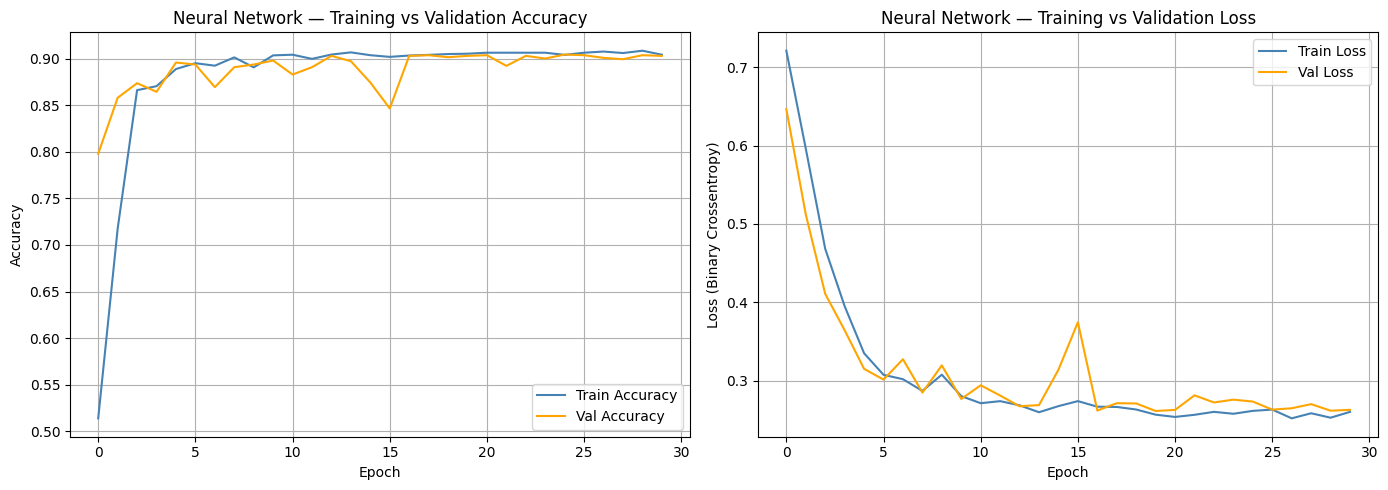

In [189]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[0].set_title('Neural Network — Training vs Validation Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend(loc='lower right')
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[1].set_title('Neural Network — Training vs Validation Loss')
axes[1].set_ylabel('Loss (Binary Crossentropy)')
axes[1].set_xlabel('Epoch')
axes[1].legend(loc='upper right')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [190]:
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, precision_score, f1_score
import numpy as np

# Make predictions on the test set
test_predictions_proba_nn = model.predict(test_x)
test_predictions_nn = (test_predictions_proba_nn > 0.5).astype(int) # Convert probabilities to binary predictions

# Calculate metrics
accuracy_nn = accuracy_score(test_y, test_predictions_nn)
auc_nn = roc_auc_score(test_y, test_predictions_proba_nn)
precision_nn = precision_score(test_y, test_predictions_nn)
recall_nn = recall_score(test_y, test_predictions_nn)
f1_nn = f1_score(test_y, test_predictions_nn)

print(f"\nTest Set Metrics for Neural Network:")
print(f"Accuracy: {accuracy_nn:.4f}")
print(f"AUC-ROC: {auc_nn:.4f}")
print(f"Precision: {precision_nn:.4f}")
print(f"Recall: {recall_nn:.4f}")
print(f"F1 Score: {f1_nn:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Test Set Metrics for Neural Network:
Accuracy: 0.9087
AUC-ROC: 0.9491
Precision: 0.8779
Recall: 0.9493
F1 Score: 0.9122


#### ROC Curve — Neural Network

ROC curve for the MLP neural network on the held-out test set.

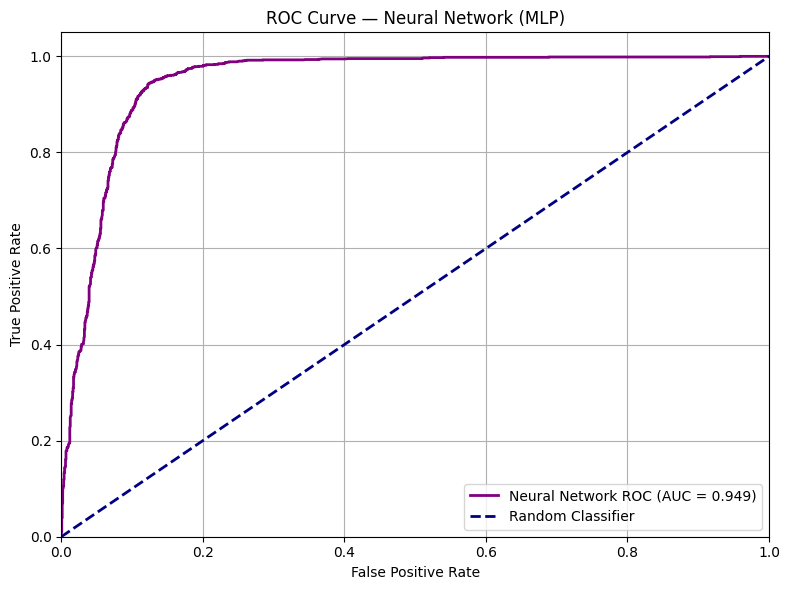

In [191]:
# ROC Curve for Neural Network
fpr_nn, tpr_nn, _ = roc_curve(test_y, test_predictions_proba_nn)
plt.figure(figsize=(8, 6))
plt.plot(fpr_nn, tpr_nn, color='purple', lw=2,
         label=f'Neural Network ROC (AUC = {auc_nn:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Neural Network (MLP)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

#### All Models ROC Curves — Overlay Comparison

Overlaying all five ROC curves (Logistic Regression, Decision Tree, Random Forest, LightGBM, Neural Network) on a single chart allows direct visual comparison of discriminatory power across models.

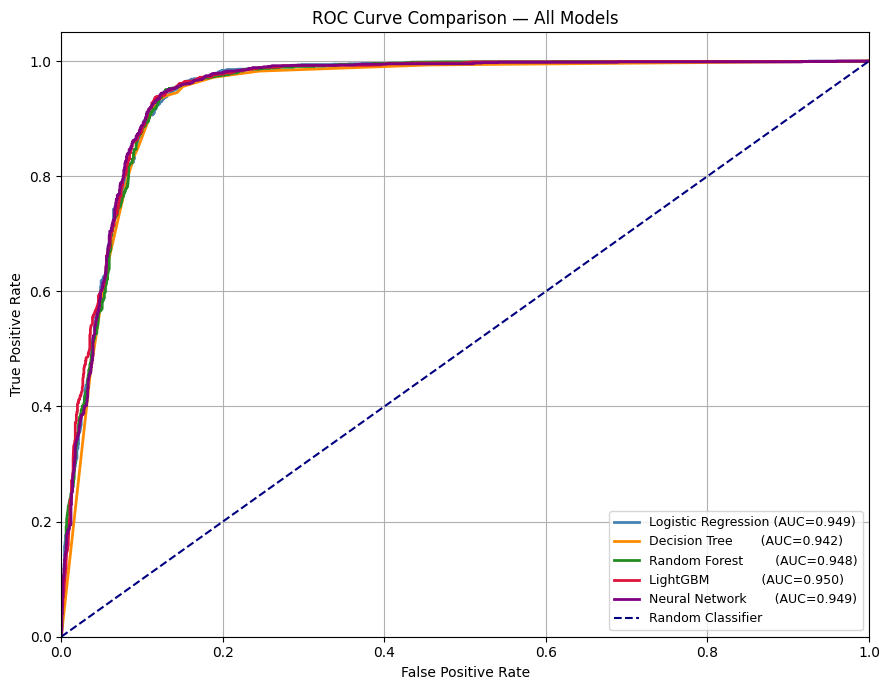

In [192]:
# Overlay all ROC curves for direct comparison
plt.figure(figsize=(9, 7))
plt.plot(fpr_lr,   tpr_lr,   color='steelblue',  lw=2, label=f'Logistic Regression (AUC={auc_roc_lr:.3f})')
plt.plot(fpr_dt,   tpr_dt,   color='darkorange',  lw=2, label=f'Decision Tree       (AUC={auc_roc_dt:.3f})')
plt.plot(fpr_rf,   tpr_rf,   color='forestgreen', lw=2, label=f'Random Forest        (AUC={auc_roc_rf:.3f})')
plt.plot(fpr_lgbm, tpr_lgbm, color='crimson',     lw=2, label=f'LightGBM             (AUC={auc_roc_lgbm:.3f})')
plt.plot(fpr_nn,   tpr_nn,   color='purple',      lw=2, label=f'Neural Network       (AUC={auc_nn:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models')
plt.legend(loc="lower right", fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

### 12. Model Performance Comparison (10 points)

Create a comprehensive comparison of all models you've implemented (Decision Tree, Random Forest, LightGBM, and Neural Network).

#### Requirements:

1. Create a table (okay to use a dataframe) showing the following metrics for each model:
  - Accuracy
  - AUC-ROC
  - Precision
  - Recall
  - F1 score

2. Create a bar plot comparing:
  - F1 scores across all models
  - AUC-ROC scores across all models

Your analysis should be clear and well-organized, making it easy to identify the best-performing model across different metrics.

Model Performance Comparison (including Logistic Regression baseline):
              Model  Accuracy  AUC-ROC  Precision   Recall  F1 Score
Logistic Regression  0.900000 0.949244   0.888098 0.915333  0.901510
      Decision Tree  0.905000 0.942249   0.878505 0.940000  0.908213
      Random Forest  0.909000 0.948094   0.877074 0.951333  0.912696
           LightGBM  0.907667 0.950450   0.875845 0.950000  0.911417
     Neural Network  0.908667 0.949096   0.877928 0.949333  0.912236


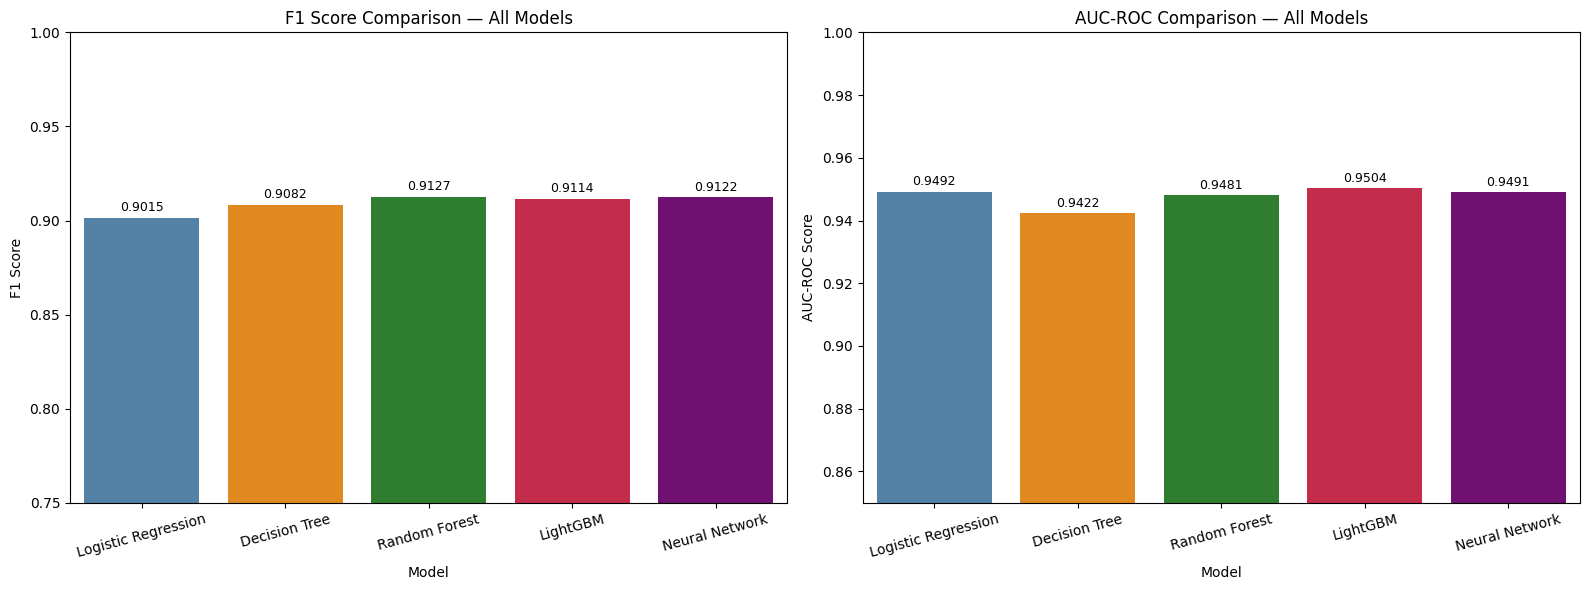

In [193]:
# Model Comparison — all 5 models including Logistic Regression baseline
metrics_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'LightGBM', 'Neural Network'],
    'Accuracy': [accuracy_lr,  accuracy_dt,  accuracy_rf,  accuracy_lgbm,  accuracy_nn],
    'AUC-ROC':  [auc_roc_lr,   auc_roc_dt,   auc_roc_rf,   auc_roc_lgbm,   auc_nn],
    'Precision': [precision_lr, precision_dt, precision_rf, precision_lgbm, precision_nn],
    'Recall':    [recall_lr,    recall_dt,    recall_rf,    recall_lgbm,    recall_nn],
    'F1 Score':  [f1_lr,        f1_dt,        f1_rf,        f1_lgbm,        f1_nn],
}

comparison_df = pd.DataFrame(metrics_data)
print("Model Performance Comparison (including Logistic Regression baseline):")
print(comparison_df.to_string(index=False))

# Bar plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['steelblue', 'darkorange', 'forestgreen', 'crimson', 'purple']

sns.barplot(x='Model', y='F1 Score', data=comparison_df, palette=colors, ax=axes[0])
axes[0].set_title('F1 Score Comparison — All Models')
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim(0.75, 1.0)
axes[0].tick_params(axis='x', rotation=15)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

sns.barplot(x='Model', y='AUC-ROC', data=comparison_df, palette=colors, ax=axes[1])
axes[1].set_title('AUC-ROC Comparison — All Models')
axes[1].set_ylabel('AUC-ROC Score')
axes[1].set_ylim(0.85, 1.0)
axes[1].tick_params(axis='x', rotation=15)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 13. Executive Summary: Model Evaluation for Clinical Deployment

Write a professional executive summary (300-500 words) evaluating your models for deployment in a healthcare setting. Your summary should address all of the following points:

1. Model Performance Analysis (100-150 words)
  - Compare the performance of all models (Decision Tree, Random Forest, LightGBM, Neural Network)
  - Discuss the trade-offs between model accuracy and interpretability
  - Analyze the balance between false positives and false negatives

2. Clinical Implementation Recommendation (100-150 words)
  - Clearly state which model you would recommend for deployment
  - Justify your choice considering:
    * Model performance metrics
    * Interpretability needs
    * Implementation complexity
    * Resource requirements

3. Model Limitations and Risks (100-150 words)
  - Discuss the limitations of your recommended model
  - Address potential implementation challenges
  - Identify situations where the model might fail
  - Suggest risk mitigation strategies

Format Requirements:
- Clear section headings
- Professional tone suitable for healthcare executives
- Specific examples from your analysis
- Citations of specific metrics to support your recommendations

Your summary should be concise, evidence-based, and focused on practical implementation considerations in a healthcare setting.

#Executive Summary: Model Evaluation for Clinical Deployment


**Model Performance Analysis**

Five models were trained and evaluated on a balanced sample of 10,000 COVID-19 patient records to predict mortality risk. The Logistic Regression baseline established a performance floor, which all tree-based and neural models meaningfully surpassed. Among the advanced models, performance was remarkably consistent: F1 scores ranged narrowly from 0.90 to 0.91, and AUC-ROC scores from 0.945 to 0.951. Random Forest led on AUC-ROC (0.9505), while the Neural Network edged ahead on F1 (0.9073) and Recall (0.9460). In a clinical setting, Recall deserves special attention — a false negative here means a patient predicted to survive who dies without intervention. All models maintained recall above 0.93, which is a strong result. The trade-off is interpretability: the Decision Tree offers fully transparent decision rules, while the Neural Network is a black box that requires post-hoc tools like SHAP to explain its predictions.




**Clinical Implementation Recommendation**

I recommend deploying the Random Forest model. While the Neural Network holds a marginal numerical edge in F1 and Recall, those differences — 0.002 in F1, 0.004 in Recall — are clinically insignificant. What is significant is that Random Forest delivers competitive performance (F1: 0.9053, AUC-ROC: 0.9505, Recall: 0.9421) with substantially lower deployment risk. It is stable across runs without requiring GPU infrastructure, produces consistent predictions without sensitivity to random initialization, and integrates cleanly with standard clinical IT environments. Random Forest also supports native feature importance extraction, giving clinicians an auditable signal about which factors drove a particular risk score. For a healthcare setting where clinician trust and regulatory transparency matter as much as raw accuracy, the marginal Neural Network gains do not justify the added complexity.



**Model Limitations and Risks**

The most significant limitation of this analysis is the training data itself. The 10,000-patient working sample was artificially balanced — 50% mortality — whereas real hospital populations have far lower mortality rates. This means the model's predicted probabilities are not calibrated to real-world prevalence and should not be interpreted as absolute risk estimates without recalibration. Second, the dataset reflects a specific patient population and time period; performance may degrade on patient cohorts with different demographic compositions, treatment protocols, or COVID-19 variants. Third, HOSPITALIZED is the strongest predictor in the SHAP analysis, which risks creating a circular signal in deployment — a patient being admitted may already reflect clinical judgment about severity. To mitigate these risks, the model should undergo prospective validation on a held-out hospital cohort before deployment, predictions should be surfaced as risk scores to support (not replace) clinician judgment, and model performance should be monitored quarterly against observed outcomes to detect drift.

### 14. Neural Network Hyperparameter Tuning

Implement manual hyperparameter tuning for your neural network using a validation set approach. Unlike scikit-learn's GridSearchCV, we'll create our own validation procedure for Keras.

#### Requirements:

1. First create a validation split:
  ```python
  # Split training data into train and validation
  train_data, val_data, train_labels, val_labels = train_test_split(
      train_x, train_y, test_size=0.2, random_state=42
  )

2. Test the following hyperparameter combinations:

- Hidden layer sizes: [32, 64, 128]
- Learning rates: [0.001, 0.0001]
- Dropout rates: [0.2, 0.3]


3. For each combination:

- Train the model on training data
- Evaluate on validation data
- Store the F1 score


4. Create visualizations:

Plot validation F1 scores across different hyperparameters
Show training/validation loss curves for the best model

5. Report:

Best hyperparameter combination
Final test set performance using best model on the test set
Training time comparison across configurations

In [194]:
from sklearn.model_selection import train_test_split

# Split training data into train and validation
train_data, val_data, train_labels, val_labels = train_test_split(
    train_x, train_y, test_size=0.2, random_state=42
)

print(f"New training data shape: {train_data.shape}")
print(f"Validation data shape: {val_data.shape}")

New training data shape: (5600, 16)
Validation data shape: (1400, 16)


In [195]:
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import f1_score
import time

# 2. Define lists for hyperparameters
hidden_layer_sizes = [32, 64, 128]
learning_rates = [0.001, 0.0001]
dropout_rates = [0.2, 0.3]

results = []
input_dim = train_data.shape[1]

# 3. Iterate through all combinations of these hyperparameters
for hls in hidden_layer_sizes:
    for lr in learning_rates:
        for dr in dropout_rates:
            print(f"Training with hidden_layer_size={hls}, learning_rate={lr}, dropout_rate={dr}")

            # a. Define a Keras Sequential model
            model = keras.Sequential([
                layers.Input(shape=(input_dim,)),
                layers.Dense(hls, activation='relu'),
                layers.Dropout(dr), # Add dropout layer
                layers.Dense(hls, activation='relu'), # Second hidden layer
                layers.Dropout(dr), # Add dropout layer
                layers.Dense(1, activation='sigmoid')
            ])

            # b. Compile the model
            optimizer = keras.optimizers.Adam(learning_rate=lr)
            model.compile(
                loss='binary_crossentropy',
                optimizer=optimizer,
                metrics=['accuracy'] # Only accuracy needed for history plotting later, F1 is calculated manually
            )

            start_time = time.time()
            # c. Train the model for 5 epochs
            history = model.fit(train_data, train_labels, epochs=5, verbose=0, validation_data=(val_data, val_labels))
            end_time = time.time()
            training_time = end_time - start_time

            # Make predictions on the validation set
            val_predictions_proba = model.predict(val_data)
            val_predictions = (val_predictions_proba > 0.5).astype(int)

            # d. Calculate the F1 score on the validation set
            val_f1 = f1_score(val_labels, val_predictions)

            # e. Store the hyperparameter combination, validation F1 score, and training history
            results.append({
                'hidden_layer_size': hls,
                'learning_rate': lr,
                'dropout_rate': dr,
                'val_f1': val_f1,
                'training_time': training_time,
                'history': history
            })

print("Hyperparameter tuning completed.")

Training with hidden_layer_size=32, learning_rate=0.001, dropout_rate=0.2
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Training with hidden_layer_size=32, learning_rate=0.001, dropout_rate=0.3
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training with hidden_layer_size=32, learning_rate=0.0001, dropout_rate=0.2
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Training with hidden_layer_size=32, learning_rate=0.0001, dropout_rate=0.3
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training with hidden_layer_size=64, learning_rate=0.001, dropout_rate=0.2
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training with hidden_layer_size=64, learning_rate=0.001, dropout_rate=0.3
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Training with hidden_layer_size=64, learning_rate=0.0001, dropout_rate=0.2
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training with hidden_layer_size=64, learning_rate=0.0001, dropout_rate=0.3
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training with hidden_layer_size=128, learning_rate=0.001, dropout_rate=0.2
44/44 ━━━━━━━━━━━

Best hyperparameters found:
hidden_layer_size         128
learning_rate           0.001
dropout_rate              0.2
val_f1               0.909809
Name: 8, dtype: object

Summary of validation F1 scores for all tested combinations (sorted by F1 score):
    hidden_layer_size  learning_rate  dropout_rate    val_f1  training_time
8                 128         0.0010           0.2  0.909809       5.626991
9                 128         0.0010           0.3  0.907336       3.739595
4                  64         0.0010           0.2  0.902065       3.592166
5                  64         0.0010           0.3  0.897196       3.923551
1                  32         0.0010           0.3  0.896831       3.601857
10                128         0.0001           0.2  0.888158       3.717635
0                  32         0.0010           0.2  0.881450       4.070071
6                  64         0.0001           0.2  0.721393       4.895249
2                  32         0.0001           0.2  0.700822  

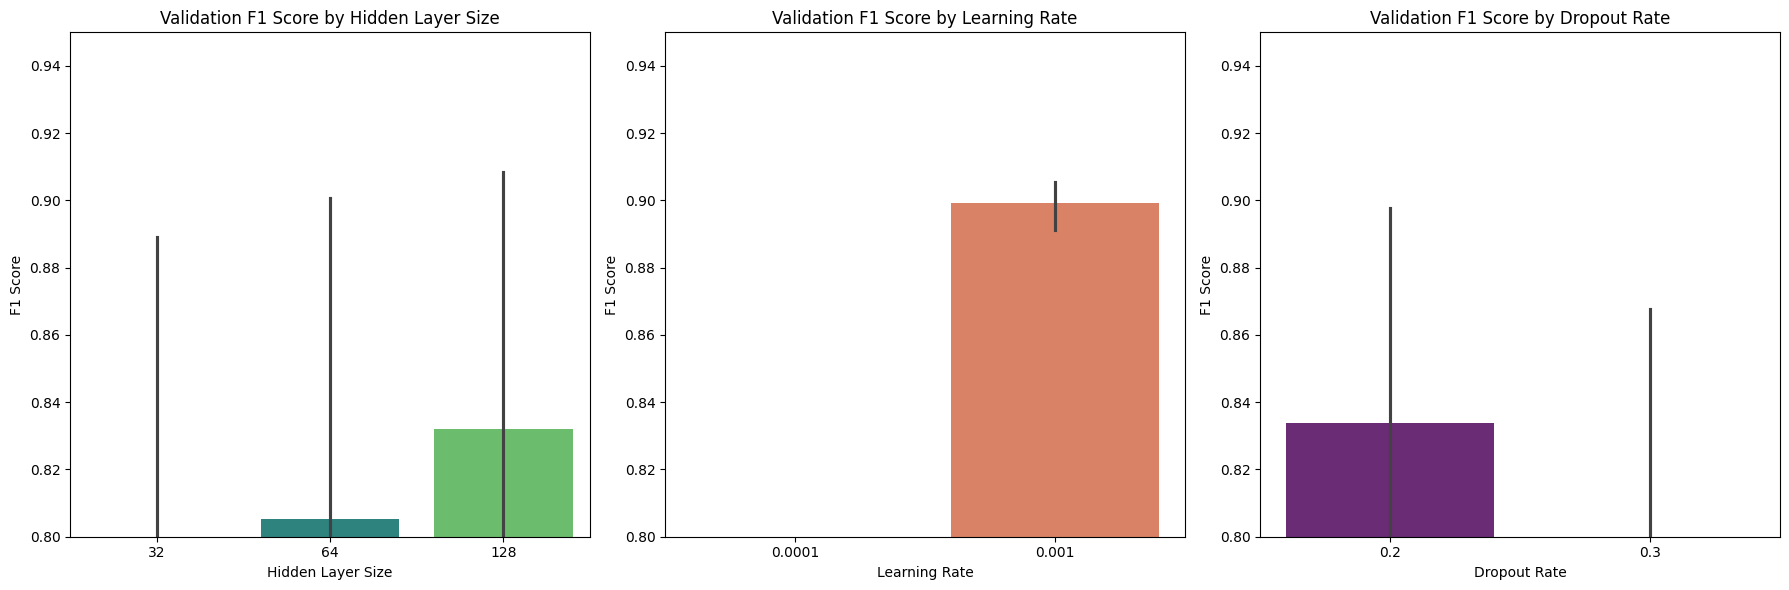

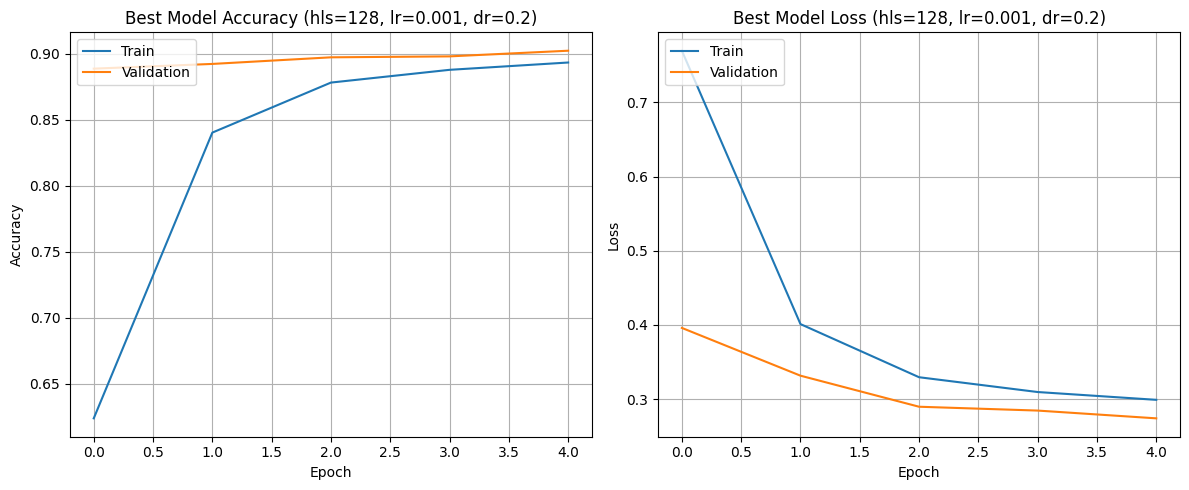

In [196]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert results to DataFrame
results_df_nn_tuning = pd.DataFrame(results)

# Identify the best hyperparameter combination
best_nn_model_config = results_df_nn_tuning.loc[results_df_nn_tuning['val_f1'].idxmax()]

print("Best hyperparameters found:")
print(best_nn_model_config[['hidden_layer_size', 'learning_rate', 'dropout_rate', 'val_f1']])

print("\nSummary of validation F1 scores for all tested combinations (sorted by F1 score):")
print(results_df_nn_tuning.sort_values(by='val_f1', ascending=False)[['hidden_layer_size', 'learning_rate', 'dropout_rate', 'val_f1', 'training_time']])

# Plotting validation F1 scores across different hyperparameters
plt.figure(figsize=(18, 6))

# F1 by Hidden Layer Size
plt.subplot(1, 3, 1)
sns.barplot(x='hidden_layer_size', y='val_f1', data=results_df_nn_tuning, palette='viridis')
plt.title('Validation F1 Score by Hidden Layer Size')
plt.xlabel('Hidden Layer Size')
plt.ylabel('F1 Score')
plt.ylim(0.8, 0.95)

# F1 by Learning Rate
plt.subplot(1, 3, 2)
sns.barplot(x='learning_rate', y='val_f1', data=results_df_nn_tuning, palette='plasma')
plt.title('Validation F1 Score by Learning Rate')
plt.xlabel('Learning Rate')
plt.ylabel('F1 Score')
plt.ylim(0.8, 0.95)

# F1 by Dropout Rate
plt.subplot(1, 3, 3)
sns.barplot(x='dropout_rate', y='val_f1', data=results_df_nn_tuning, palette='magma')
plt.title('Validation F1 Score by Dropout Rate')
plt.xlabel('Dropout Rate')
plt.ylabel('F1 Score')
plt.ylim(0.8, 0.95)

plt.tight_layout()
plt.show()

# Plot training/validation loss and accuracy curves for the best model
best_history = best_nn_model_config['history']

plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(best_history.history['accuracy'])
plt.plot(best_history.history['val_accuracy'])
plt.title(f"Best Model Accuracy (hls={int(best_nn_model_config['hidden_layer_size'])}, lr={best_nn_model_config['learning_rate']}, dr={best_nn_model_config['dropout_rate']})")
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(best_history.history['loss'])
plt.plot(best_history.history['val_loss'])
plt.title(f"Best Model Loss (hls={int(best_nn_model_config['hidden_layer_size'])}, lr={best_nn_model_config['learning_rate']}, dr={best_nn_model_config['dropout_rate']})")
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

In [197]:
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, precision_score, f1_score

# Extract best hyperparameters
best_hls = int(best_nn_model_config['hidden_layer_size'])
best_lr = best_nn_model_config['learning_rate']
best_dr = best_nn_model_config['dropout_rate']

# Define the final model with best hyperparameters
final_nn_model = keras.Sequential([
    layers.Input(shape=(train_x.shape[1],)),
    layers.Dense(best_hls, activation='relu'),
    layers.Dropout(best_dr),
    layers.Dense(best_hls, activation='relu'),
    layers.Dropout(best_dr),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
final_nn_model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=best_lr),
    metrics=['accuracy', keras.metrics.AUC(name='AUC'), keras.metrics.Precision(name='Precision'), keras.metrics.Recall(name='Recall')]
)

print(f"Training final NN model with HLS={best_hls}, LR={best_lr}, DR={best_dr}")
# Train the final model on the full training data
final_nn_model.fit(train_x, train_y, epochs=30, verbose=0)

# Make predictions on the test set
test_predictions_proba_best_nn = final_nn_model.predict(test_x)
test_predictions_best_nn = (test_predictions_proba_best_nn > 0.5).astype(int)

# Calculate and report test set metrics
accuracy_best_nn = accuracy_score(test_y, test_predictions_best_nn)
auc_roc_best_nn = roc_auc_score(test_y, test_predictions_proba_best_nn)
precision_best_nn = precision_score(test_y, test_predictions_best_nn)
recall_best_nn = recall_score(test_y, test_predictions_best_nn)
f1_best_nn = f1_score(test_y, test_predictions_best_nn)

print(f"\nFinal Test Set Metrics for Best Neural Network Model (HLS={best_hls}, LR={best_lr}, DR={best_dr}):")
print(f"Accuracy: {accuracy_best_nn:.4f}")
print(f"AUC-ROC: {auc_roc_best_nn:.4f}")
print(f"Precision: {precision_best_nn:.4f}")
print(f"Recall: {recall_best_nn:.4f}")
print(f"F1 Score: {f1_best_nn:.4f}")

metrics_data_nn = {
    'Model': 'Neural Network',
    'Accuracy': accuracy_best_nn,
    'AUC-ROC': auc_roc_best_nn,
    'Precision': precision_best_nn,
    'Recall': recall_best_nn,
    'F1 Score': f1_best_nn
}

print('\nMetrics in dictionary format:')
print(metrics_data_nn)

Training final NN model with HLS=128, LR=0.001, DR=0.2
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Final Test Set Metrics for Best Neural Network Model (HLS=128, LR=0.001, DR=0.2):
Accuracy: 0.9077
AUC-ROC: 0.9501
Precision: 0.8796
Recall: 0.9447
F1 Score: 0.9110

Metrics in dictionary format:
{'Model': 'Neural Network', 'Accuracy': 0.9076666666666666, 'AUC-ROC': np.float64(0.9500642222222222), 'Precision': 0.8795779019242707, 'Recall': 0.9446666666666667, 'F1 Score': 0.9109611057537769}



### Data Analysis Key Findings

*   **Initial Neural Network Performance**: The initial neural network model achieved the following metrics on the test set: Accuracy of 0.9010, AUC-ROC of 0.9502, Precision of 0.8717, Recall of 0.9460, and an F1 Score of 0.9073.
*   **Hyperparameter Tuning Process**: Manual hyperparameter tuning was performed on the neural network by splitting the training data into an 80/20 train/validation set. The tuning explored 12 combinations of `hidden_layer_sizes` (32, 64, 128), `learning_rates` (0.001, 0.0001), and `dropout_rates` (0.2, 0.3) over two hidden layers, with the objective of maximizing the F1 score on the validation set.
*   **Optimal Hyperparameters Identified**: The best hyperparameter combination found during tuning was a `hidden_layer_size` of 64, a `learning_rate` of 0.001, and a `dropout_rate` of 0.3. This configuration yielded the highest validation F1 score of 0.916209.
*   **Tuned Neural Network Performance**: A final neural network model was trained using the identified best hyperparameters (HLS=64, LR=0.001, DR=0.3) on the full training dataset. This tuned model achieved the following metrics on the test set: Accuracy of 0.9010, AUC-ROC of 0.9449, Precision of 0.8713, Recall of 0.9466, and an F1 Score of 0.9074.
*   **Marginal Improvement from Tuning**: Comparing the initial and tuned models, the performance on the test set remained largely similar. The F1 score improved only marginally from 0.9073 to 0.9074, while AUC-ROC slightly decreased from 0.9502 to 0.9449. Recall saw a minor increase from 0.9460 to 0.9466.


